In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4203,4291-YZODP,Female,0,No,Yes,7,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.05,96.8,No
2271,0093-EXYQL,Female,1,No,No,40,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,91.55,3673.6,No
6148,8990-YOZLV,Female,0,No,No,69,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Mailed check,66.90,4577.9,No
3181,1265-ZFOSD,Female,0,Yes,No,64,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Two year,Yes,Mailed check,81.30,5129.3,No
6330,9921-QFQUL,Female,0,Yes,No,23,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,No,Mailed check,90.15,2044.95,No


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
numericColumns=["TotalCharges", "MonthlyCharges", "tenure", "SeniorCitizen"]
for i in range(len(numericColumns)):
    df[numericColumns[i]]=pd.to_numeric(df[numericColumns[i]], errors="coerce")

In [24]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [25]:
indexes=df[df["TotalCharges"].isnull()].index

In [26]:
df.loc[df["TotalCharges"].isnull(),"TotalCharges"]

488    NaN
753    NaN
936    NaN
1082   NaN
1340   NaN
3331   NaN
3826   NaN
4380   NaN
5218   NaN
6670   NaN
6754   NaN
Name: TotalCharges, dtype: float64

In [27]:
df.loc[df["TotalCharges"].isnull(),"TotalCharges"]=df.loc[df["TotalCharges"].isnull(),"tenure"]*df.loc[df["TotalCharges"].isnull(), "MonthlyCharges"]

In [28]:
df.iloc[indexes]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [29]:
indexes=(df[df["TotalCharges"]==0]).index


In [30]:
indexes

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [31]:
df.drop(indexes,inplace=True)

In [32]:
df.iloc[indexes,:]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
489,8372-JUXUI,Male,0,No,Yes,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.35,74.35,Yes
755,6683-VLCTZ,Male,1,No,No,20,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.55,1842.80,Yes
939,0347-UBKUZ,Female,0,No,No,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,320.45,No
1086,8999-BOHSE,Female,1,No,No,11,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),89.70,1047.70,Yes
1345,2293-IJWPS,Female,0,Yes,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),100.75,5985.00,No
3337,0840-DFEZH,Female,0,No,No,7,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.35,564.65,No
3833,9169-BSVIN,Male,0,No,No,12,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),74.75,827.05,No
4388,3525-DVKFN,Female,0,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.40,358.05,No
5227,4060-LDNLU,Male,0,No,No,7,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,96.20,639.70,No
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.drop(columns=["customerID"], inplace=True)

In [18]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
for col in df.columns:
    if df[col].dtype!="object": continue
    print(df[col].value_counts(), end="\n \n")

gender
Male      3549
Female    3483
Name: count, dtype: int64
 
Partner
No     3639
Yes    3393
Name: count, dtype: int64
 
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
 
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
 
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
 
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
 
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64
 
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64
 
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64
 
TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64
 
StreamingTV
No       

In [16]:
gender=["Male", "Female"]
yn = ["No", "Yes"]
ynn = ["No phone service", "No", "Yes"]
internetService = ["No", "DSL", "Fiber optic"]
ynn1 = ["No internet service", "No", "Yes"]
contract=["Month-to-month", "One year", "Two year"]
paymentMethod=["Electronic check","Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]


In [23]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
pd.DataFrame([df.quantile(0.975, numeric_only=True), df.quantile(0.025, numeric_only=True), df.mean(numeric_only=True)-(3*df.std(numeric_only=True)), df.mean(numeric_only=True)+(3*df.std(numeric_only=True)), df.min(numeric_only=True), df.max(numeric_only=True)], index=["97.5%", "2.5%", "mean-3*std", "mean+3*std", "min", "max"] )

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
97.5%,1.000000,72.000000,110.750000,7554.263750
2.5%,0.000000,1.000000,19.400000,24.877500
mean-3*std,-0.944132,-41.213993,-25.459713,-4517.013645
mean+3*std,1.268932,106.057565,155.056130,9083.614526
min,0.000000,1.000000,18.250000,18.800000
max,1.000000,72.000000,118.750000,8684.800000


- `mean-3*std`, `mean+3*std` working nowhere

In [ ]:
df.quantile(1/4, numeric_only=True) - 1.5*(df.quantile(3/4, numeric_only=True)-df.quantile(1/4, numeric_only=True)),df.quantile(3/4, numeric_only=True) + 1.5*(df.quantile(3/4, numeric_only=True)-df.quantile(1/4, numeric_only=True))

(SeniorCitizen        0.00000
 tenure             -60.00000
 MonthlyCharges     -45.82500
 TotalCharges     -4688.48125
 dtype: float64,
 SeniorCitizen        0.00000
 tenure             124.00000
 MonthlyCharges     171.27500
 TotalCharges      8884.66875
 dtype: float64)

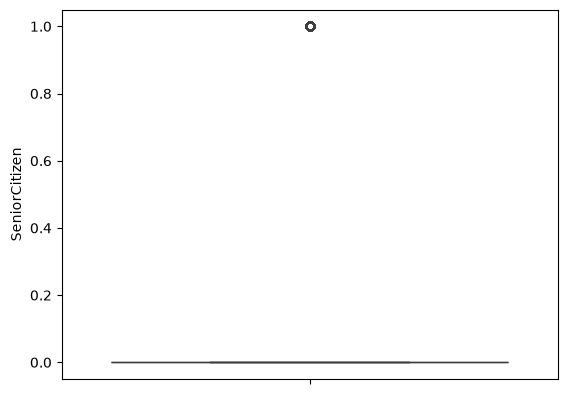

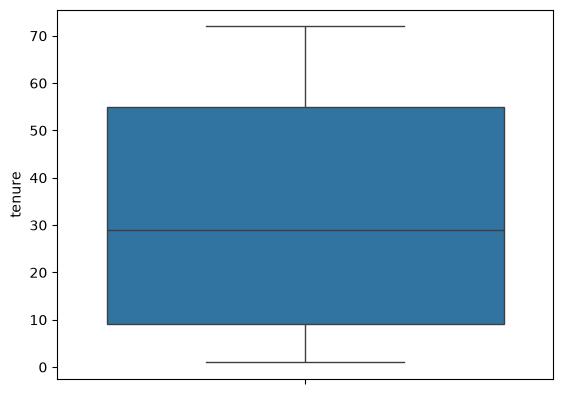

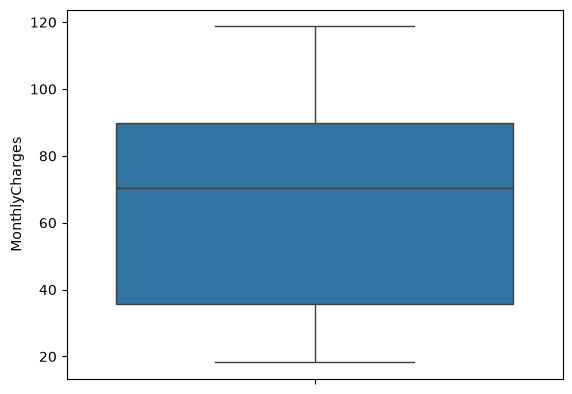

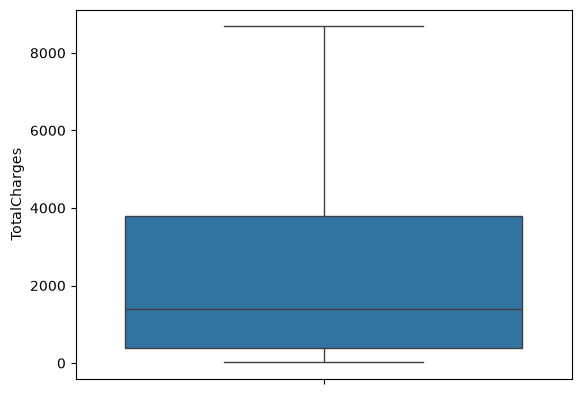

In [ ]:
for col in df.columns:
    if df[col].dtype==object:continue
    sns.boxplot(df[col])
    plt.show()

In [ ]:
df[(df["MonthlyCharges"]>df["MonthlyCharges"].quantile(0.975)) ]["InternetService"].value_counts()

InternetService
Fiber optic    175
Name: count, dtype: int64

In [ ]:
df[(df["MonthlyCharges"]<df["MonthlyCharges"].quantile(0.025)) ]["InternetService"].value_counts()

InternetService
No    149
Name: count, dtype: int64

In [ ]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

no need of outlier handling as we didn't find any of the outlier using z-score method and IQR method and graphs also can't plot outliers so....

# Train-test Split

In [ ]:
X = df.iloc[:, :-1].drop(columns=["TotalCharges"])
y = df.iloc[:, -1]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
6030,Female,0,No,No,43,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),49.05
3410,Male,0,No,No,3,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Credit card (automatic),53.40
5483,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,77.75
5524,Male,0,Yes,Yes,45,Yes,No,DSL,Yes,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),54.65
6337,Female,0,Yes,Yes,55,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,One year,No,Mailed check,100.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,Male,0,No,No,3,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),50.40
5199,Female,0,No,No,51,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,111.50
5235,Male,0,No,No,9,Yes,Yes,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,81.15
5399,Female,0,No,No,50,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.75


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

In [ ]:
def zscore(arr):
    return ((arr-arr.mean())/arr.std()).mean()

In [ ]:
arr = np.array([1,2,3,4,5,6,7,8,12])
print(zscore(arr))

9.868649107779169e-17


8.285623482981828e-17


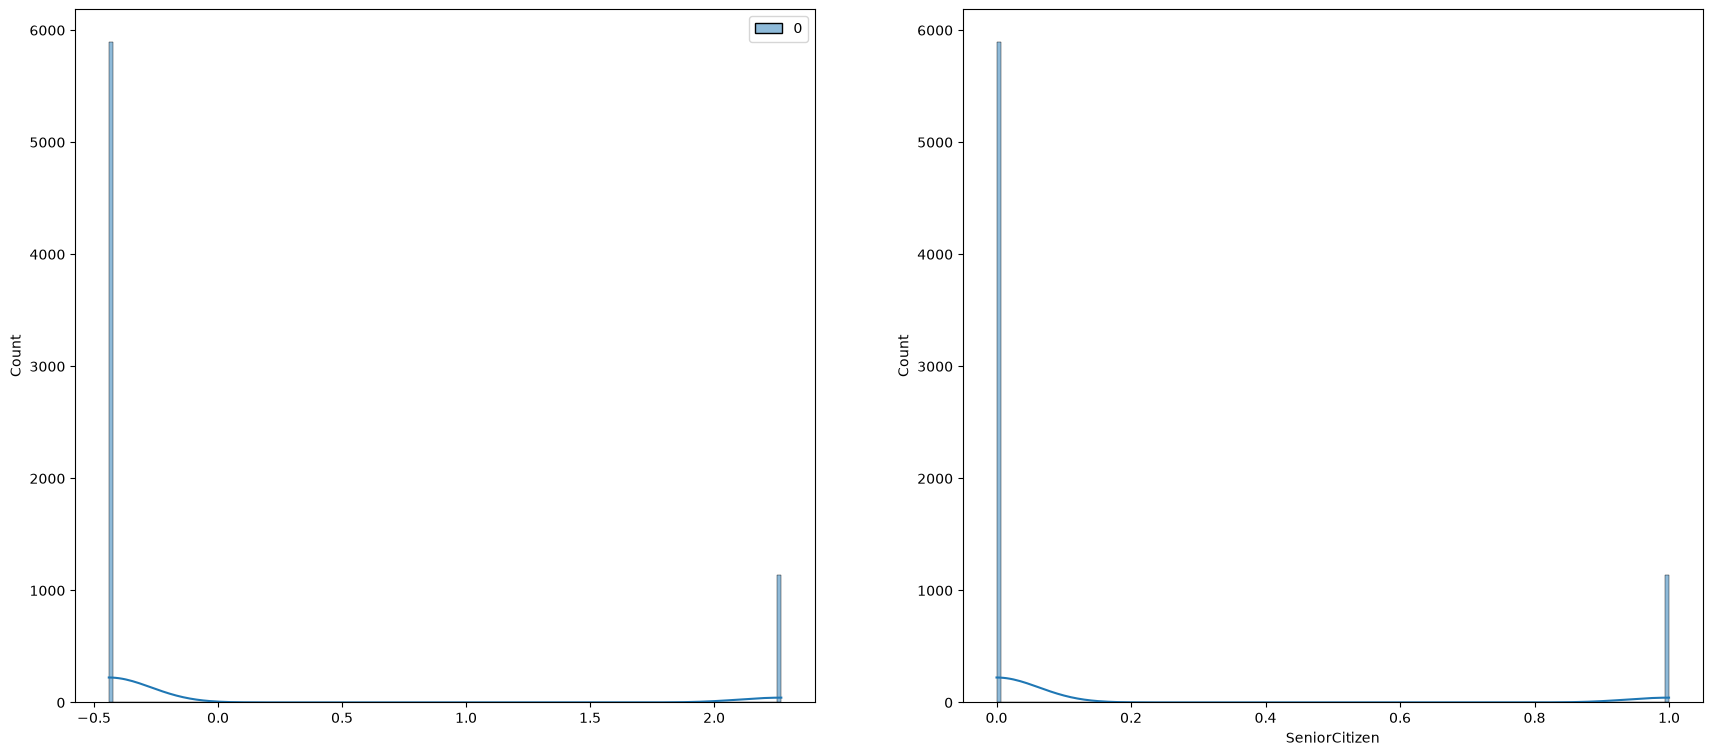

3.2839361365476755e-17


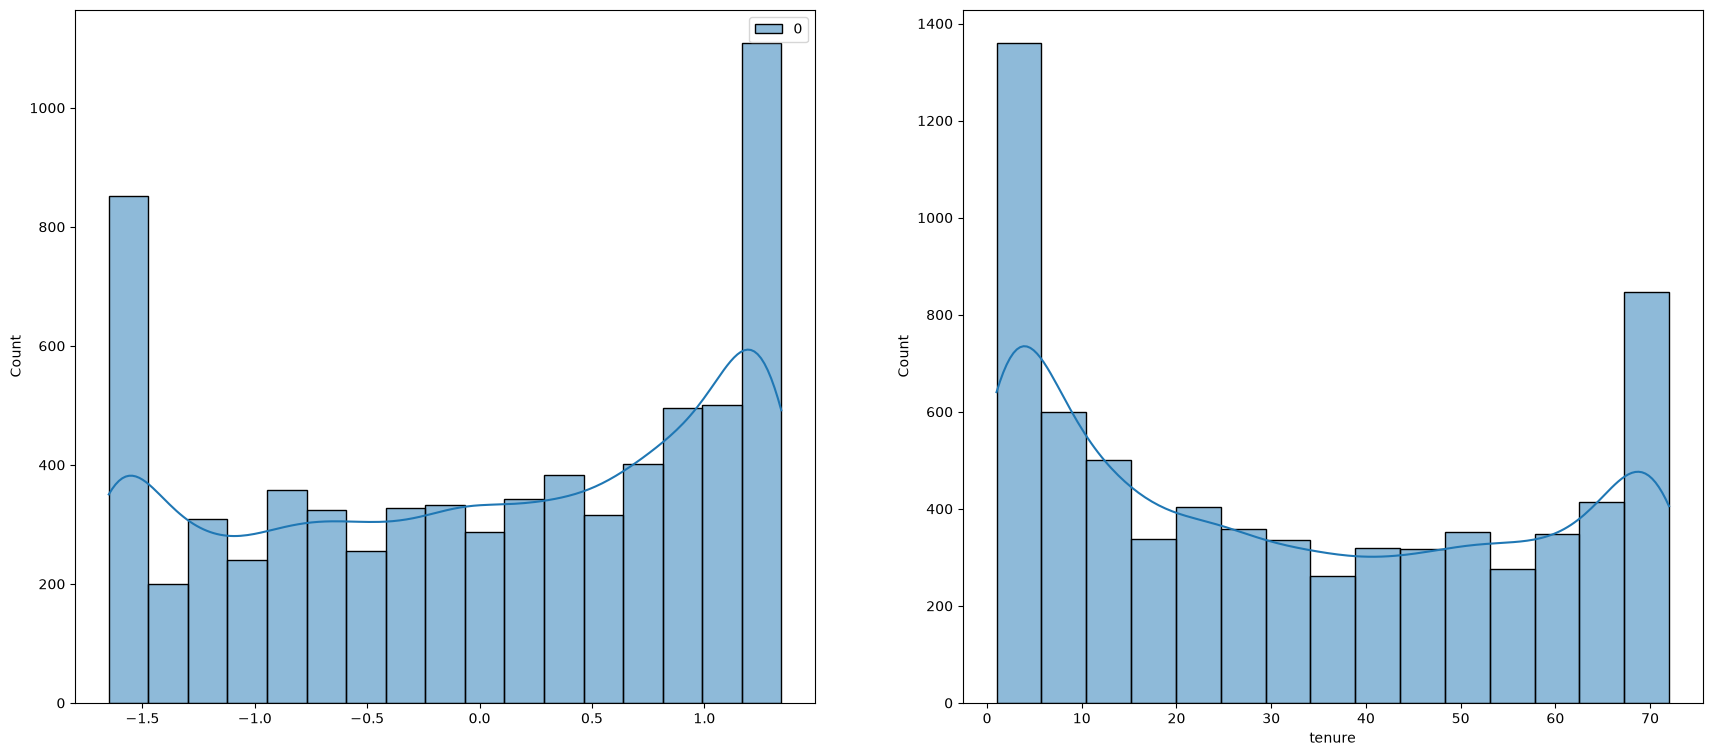

3.688112891815082e-17


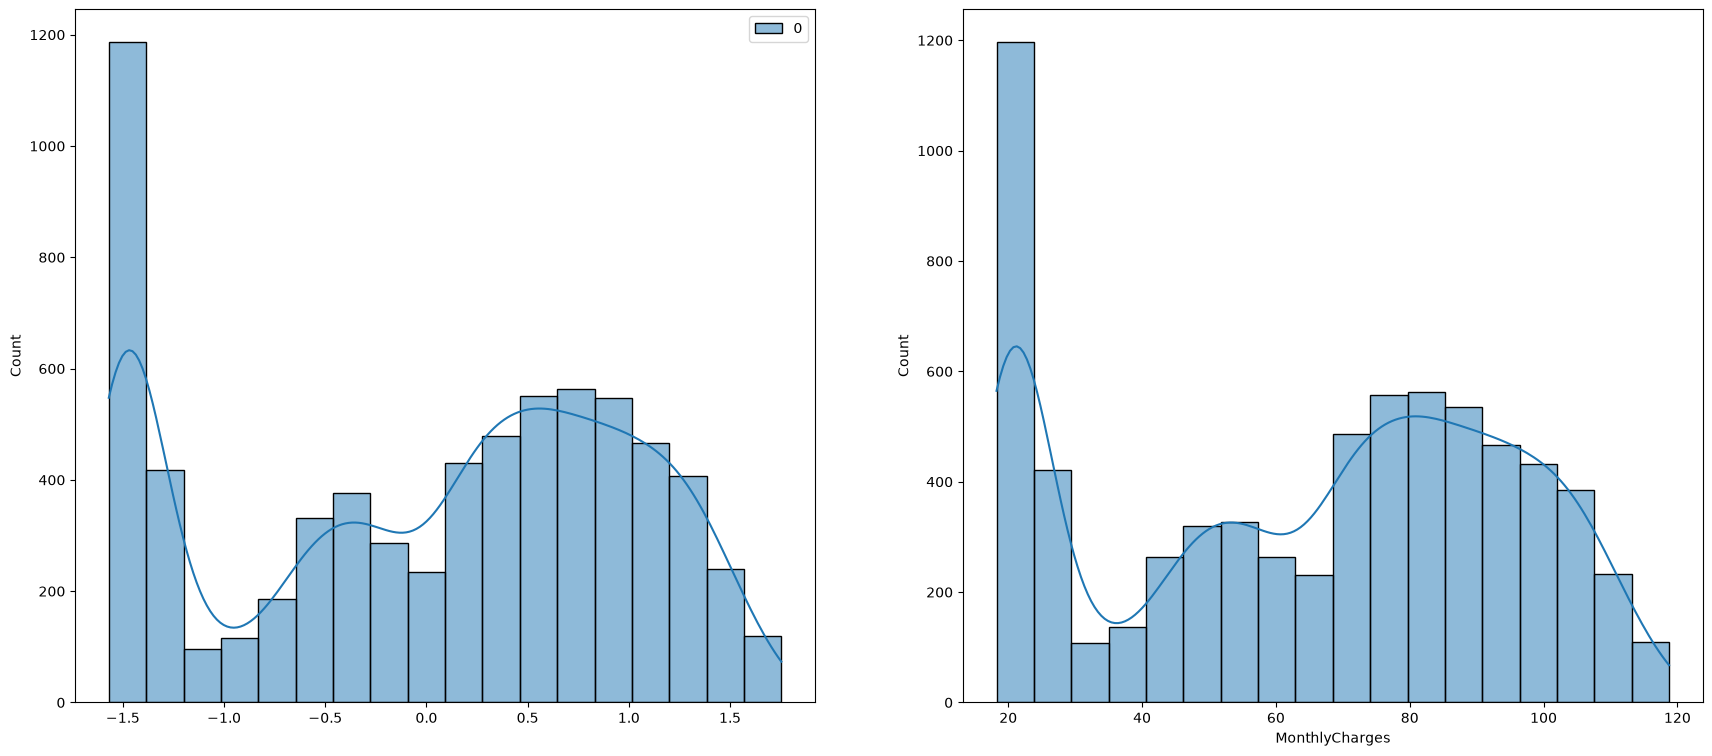

2.3745384371960118e-17


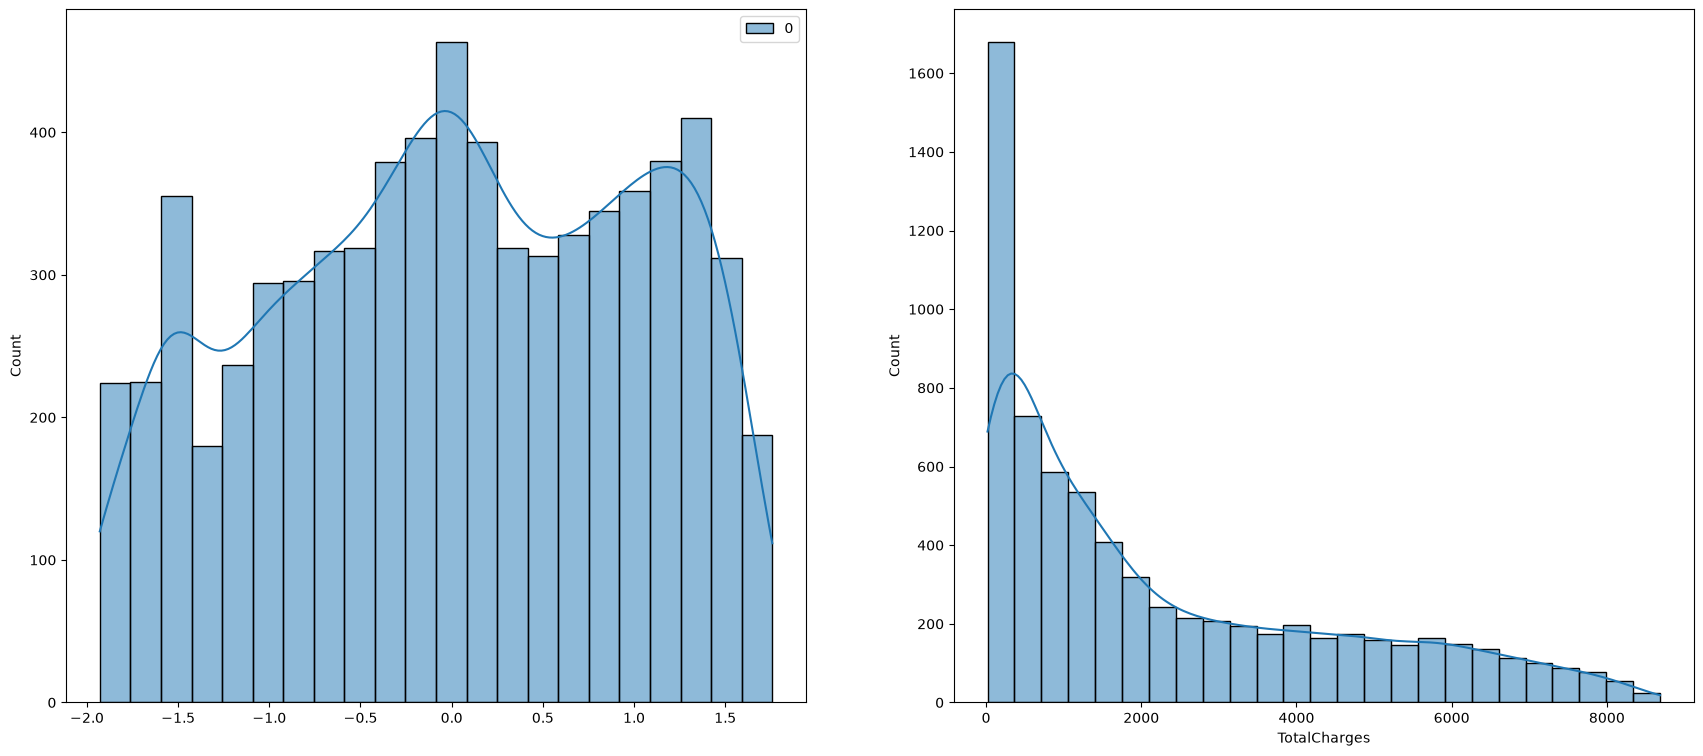

In [ ]:
for col in df.columns:
    if df[col].dtype==object:continue
    plt.figure(figsize=(21,9))
    plt.subplot(121)
    transformer=PowerTransformer(method="yeo-johnson")
    pseudoCol=transformer.fit_transform(df[col].values.reshape(-1,1))
    sns.histplot(pseudoCol, kde=True)
    print(zscore(pseudoCol))
    plt.subplot(122)
    sns.histplot(df[col], kde=True)
    plt.show()

power transformer shows no major difference in distribution

In [ ]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges'],
      dtype='object')

In [ ]:
for col in df.columns:
    if df[col].dtype==object:continue
    print(col, end='", "')

SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
featureResembling= ColumnTransformer(
    [
        ("ohe", OneHotEncoder(sparse_output=False), ["InternetService", "gender", "PaymentMethod", "Contract"]),
        (
            "oeYn", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[yn]*4)),
                ("scaler", MinMaxScaler()),
            ]
            ), 
            ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
            ),
        (
            "oeYnn", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[ynn])),
                ("scaler", MinMaxScaler())
            ]
            ), 
            ["MultipleLines"]
            ),
        (
            "oeYnn1", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[ynn1]*6)),
                ("scaler", MinMaxScaler())
            ]
            ) 
            ,["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
            ),
        ("stdScaling", Pipeline(
            [
                ("poly", PolynomialFeatures(degree=3)),
                ("scaling",StandardScaler())
                ]
            ), ["tenure", "MonthlyCharges"])
        ], remainder="passthrough"
)

In [ ]:
X_train_transformed=featureResembling.fit_transform(X_train)
X_test_transformed=featureResembling.transform(X_test)

In [ ]:
X_train_transformed

array([[ 1.        ,  0.        ,  0.        , ..., -0.3717147 ,
        -0.77982348,  0.        ],
       [ 1.        ,  0.        ,  0.        , ..., -0.77189221,
        -0.69722734,  0.        ],
       [ 0.        ,  1.        ,  0.        , ...,  0.59405293,
         0.06869201,  0.        ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.55804102,
         0.22392308,  0.        ],
       [ 0.        ,  0.        ,  1.        , ..., -0.72572402,
        -1.04572615,  0.        ],
       [ 0.        ,  1.        ,  0.        , ..., -0.35049269,
        -0.10126044,  1.        ]], shape=(5625, 34))

In [ ]:
outputColumnResembler=LabelEncoder()
y_train_transformed=outputColumnResembler.fit_transform(y_train)
y_test_transformed=outputColumnResembler.transform(y_test)
y_train_transformed


array([1, 1, 1, ..., 0, 0, 1], shape=(5625,))

In [ ]:
y_train

6030    Yes
3410    Yes
5483    Yes
5524     No
6337     No
       ... 
3778     No
5199     No
5235     No
5399     No
862     Yes
Name: Churn, Length: 5625, dtype: object

In [ ]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
smote = SMOTE(random_state=42)
ros = RandomOverSampler(random_state=42)
rus = RandomUnderSampler(random_state=42)

In [49]:
X_train_transformed, y_train_transformed= smote.fit_resample(X_train_transformed, y_train_transformed)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [51]:
lr=LogisticRegression(max_iter=200)
knn = KNeighborsClassifier(n_neighbors=15)
dt = DecisionTreeClassifier()
svc = SVC()
rfc = RandomForestClassifier(n_estimators=175, max_samples=92, min_samples_leaf=14, max_depth=8)

In [52]:
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, precision_score, classification_report

In [53]:
lr.fit(X_train_transformed, y_train_transformed)
confusion_matrix(y_test_transformed,lr.predict(X_test_transformed)), recall_score(y_test_transformed,lr.predict(X_test_transformed)), accuracy_score(y_test_transformed,lr.predict(X_test_transformed))


(array([[735, 298],
        [ 74, 300]]),
 0.8021390374331551,
 0.7356076759061834)

In [54]:
knn.fit(X_train_transformed, y_train_transformed)
confusion_matrix(y_test_transformed,knn.predict(X_test_transformed)), recall_score(y_test_transformed,knn.predict(X_test_transformed)), accuracy_score(y_test_transformed,knn.predict(X_test_transformed))


(array([[680, 353],
        [ 73, 301]]),
 0.8048128342245989,
 0.697228144989339)

In [55]:
svc.fit(X_train_transformed, y_train_transformed)
confusion_matrix(y_test_transformed,svc.predict(X_test_transformed)), recall_score(y_test_transformed,svc.predict(X_test_transformed)), accuracy_score(y_test_transformed,svc.predict(X_test_transformed))


(array([[749, 284],
        [ 88, 286]]),
 0.7647058823529411,
 0.7356076759061834)

In [56]:
dt.fit(X_train_transformed, y_train_transformed)
confusion_matrix(y_test_transformed,dt.predict(X_test_transformed)), recall_score(y_test_transformed,dt.predict(X_test_transformed)), accuracy_score(y_test_transformed,dt.predict(X_test_transformed))


(array([[810, 223],
        [174, 200]]),
 0.5347593582887701,
 0.7178393745557925)

In [57]:
rfc.fit(X_train_transformed, y_train_transformed)
confusion_matrix(y_test_transformed,rfc.predict(X_test_transformed)), recall_score(y_test_transformed,rfc.predict(X_test_transformed)), accuracy_score(y_test_transformed,rfc.predict(X_test_transformed))


(array([[756, 277],
        [ 82, 292]]),
 0.7807486631016043,
 0.7448471926083866)

In [58]:
rfc.n_estimators

175

1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done
9 done
10 done
11 done
12 done
13 done
14 done
15 done
16 done
17 done
18 done
19 done
20 done
21 done
22 done
23 done
24 done
25 done
26 done
27 done
28 done
29 done
30 done
31 done
32 done
33 done
34 done
35 done
36 done
37 done
38 done
39 done
40 done
41 done
42 done
43 done
44 done
45 done
46 done
47 done
48 done
49 done
50 done
51 done
52 done
53 done
54 done
55 done
56 done
57 done
58 done
59 done
60 done
61 done
62 done
63 done
64 done
65 done
66 done
67 done
68 done
69 done
70 done
71 done
72 done


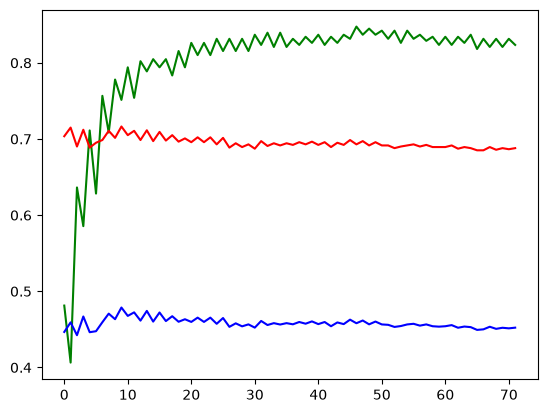

In [59]:
precise=list()
accurate=list()
precision = list()
for i in range(1,73):
    knn = KNeighborsClassifier(n_neighbors=i, n_jobs=-1)
    knn.fit(X_train_transformed, y_train_transformed)
    precise.append(recall_score(y_test_transformed,knn.predict(X_test_transformed)))
    precision.append(precision_score(y_test_transformed,knn.predict(X_test_transformed)))

    accurate.append(accuracy_score(y_test_transformed,knn.predict(X_test_transformed)))
    print(i, "done")

plt.plot(precise, color="green")
plt.plot(accurate, color="red")
plt.plot(precision, color="blue")

plt.show()



In [60]:
enumerate(precise)
big=0
for i in enumerate(precise):
    if i[1]>big: 
        big=i[1]
        print(i)

(0, 0.48128342245989303)
(2, 0.6363636363636364)
(4, 0.7112299465240641)
(6, 0.7566844919786097)
(8, 0.7780748663101604)
(10, 0.7941176470588235)
(12, 0.8021390374331551)
(14, 0.8048128342245989)
(18, 0.8155080213903744)
(20, 0.8262032085561497)
(24, 0.8315508021390374)
(30, 0.8368983957219251)
(32, 0.839572192513369)
(46, 0.8475935828877005)


In [59]:
from sklearn.ensemble import StackingClassifier


In [60]:
sc=StackingClassifier(estimators=[
    ("lr", LogisticRegression(max_iter=200)),
    ("rf", RandomForestClassifier(n_estimators=200, max_samples=92, min_samples_leaf=14, max_depth=8))

], )

In [61]:
sc.fit(X_train_transformed, y_train_transformed)
confusion_matrix(y_test_transformed,sc.predict(X_test_transformed)), recall_score(y_test_transformed,sc.predict(X_test_transformed)), accuracy_score(y_test_transformed,sc.predict(X_test_transformed))


(array([[752, 281],
        [ 76, 298]]),
 0.7967914438502673,
 0.746268656716418)

In [52]:
import optuna

/home/archit/Documents/chaiAurCode/100DaysOfMl/Projects/project1/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# logistic reg investigation

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [99]:
def objectiveFunction(trials):
    max_iter=trials.suggest_int("max_iter", 100, 750, step=5)
    C = trials.suggest_float("c", 0.1, 200, log=True)

    model = LogisticRegression(max_iter=max_iter, C=C)
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=5, scoring="f1").mean()

In [100]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=250)

[I 2026-09-06 14:15:08,503] A new study created in memory with name: no-name-7c0f58a3-bd1a-4d7a-92a5-376f33697667
[I 2026-09-06 14:15:12,792] Trial 0 finished with value: 0.5981025668870708 and parameters: {'max_iter': 575, 'c': 48.83554920281807}. Best is trial 0 with value: 0.5981025668870708.
[I 2026-09-06 14:15:14,673] Trial 1 finished with value: 0.60133383233562 and parameters: {'max_iter': 460, 'c': 0.3027804256849224}. Best is trial 1 with value: 0.60133383233562.
[I 2026-09-06 14:15:16,282] Trial 2 finished with value: 0.6006369584495921 and parameters: {'max_iter': 605, 'c': 8.34711050600839}. Best is trial 1 with value: 0.60133383233562.
[I 2026-09-06 14:15:18,285] Trial 3 finished with value: 0.5978447448840354 and parameters: {'max_iter': 560, 'c': 12.303353252879461}. Best is trial 1 with value: 0.60133383233562.
[I 2026-09-06 14:15:20,470] Trial 4 finished with value: 0.60022569099172 and parameters: {'max_iter': 380, 'c': 188.29901829901695}. Best is trial 1 with value:

In [101]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.60].describe()

,number,value,datetime_start,datetime_complete,duration,params_c,params_max_iter
count,230.000000,230.000000,230,230,230,230.000000,230.000000
mean,131.291304,0.604579,2026-09-06 14:18:19.423129344,2026-09-06 14:18:20.796608512,0 days 00:00:01.373479191,2.179788,244.108696
min,1.000000,0.600061,2026-09-06 14:15:12.799138,2026-09-06 14:15:14.673591,0 days 00:00:00.889020,0.302780,100.000000
25%,74.250000,0.603828,2026-09-06 14:17:07.379878656,2026-09-06 14:17:08.771599360,0 days 00:00:01.147046,0.892380,200.000000
50%,132.500000,0.605095,2026-09-06 14:18:21.419979520,2026-09-06 14:18:22.823609600,0 days 00:00:01.262425,1.111841,230.000000
75%,190.750000,0.605740,2026-09-06 14:19:34.837119488,2026-09-06 14:19:36.418482432,0 days 00:00:01.458886500,1.370322,260.000000
max,249.000000,0.606868,2026-09-06 14:20:57.709355,2026-09-06 14:20:58.831304,0 days 00:00:04.448574,188.299018,735.000000
std,69.949248,0.001648,NaN,NaN,0 days 00:00:00.390763999,12.412395,94.090505


In [102]:
study.trials_dataframe().corr(numeric_only=True)

,number,value,params_c,params_max_iter
number,1.000000,0.495819,-0.166634,-0.236223
value,0.495819,1.000000,-0.385175,-0.336658
params_c,-0.166634,-0.385175,1.000000,0.078668
params_max_iter,-0.236223,-0.336658,0.078668,1.000000


In [103]:
study.best_params

{'max_iter': 200, 'c': 1.0214844984866578}

In [117]:
from sklearn.metrics import roc_curve, classification_report
lr = LogisticRegression(max_iter=490, C=92.57004631255585)
lr.fit(X_train_transformed, y_train_transformed)
y_score=lr.predict_proba(X_test_transformed)
y_pred=lr.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))


0.4679144385026738
0.7867803837953091
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

[[932 101]
 [199 175]]


In [119]:
from sklearn.metrics import roc_curve, classification_report
lr = LogisticRegression(max_iter=200, C=1.0214844984866578)
lr.fit(X_train_transformed, y_train_transformed)
y_score=lr.predict_proba(X_test_transformed)
y_pred=lr.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))


0.4839572192513369
0.7896233120113717
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[930 103]
 [193 181]]


In [120]:

fpr, tpr, thresholds = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax(tpr**1.5-fpr)
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<thresholds[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8609625668449198
0.7036247334754797
              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1033
           1       0.47      0.86      0.61       374

    accuracy                           0.70      1407
   macro avg       0.70      0.75      0.68      1407
weighted avg       0.81      0.70      0.72      1407

[[668 365]
 [ 52 322]]


In [66]:
(thresholds)

array([       inf, 0.97865163, 0.97025755, 0.9669634 , 0.96104548,
       0.95745776, 0.95469912, 0.95408167, 0.94784209, 0.9476261 ,
       0.91497656, 0.91451827, 0.91024082, 0.90916523, 0.90204568,
       0.90200451, 0.90174502, 0.90130245, 0.89229816, 0.89167014,
       0.8867972 , 0.88518037, 0.88509122, 0.88415527, 0.88211445,
       0.88042599, 0.87359152, 0.86944308, 0.86791263, 0.86642042,
       0.86594917, 0.864556  , 0.86127411, 0.86024531, 0.85860347,
       0.85843706, 0.85840571, 0.85733458, 0.8554922 , 0.85386608,
       0.85198107, 0.85169184, 0.84770648, 0.84603947, 0.84558062,
       0.84396021, 0.83615682, 0.82770065, 0.82731532, 0.82709762,
       0.82694731, 0.82270229, 0.82265774, 0.81861116, 0.81493946,
       0.81441506, 0.81395311, 0.81081788, 0.8042314 , 0.79955859,
       0.79816128, 0.79775608, 0.79545724, 0.79443332, 0.79293258,
       0.79240973, 0.79155216, 0.79074712, 0.78416125, 0.78375808,
       0.78322504, 0.78318751, 0.78220273, 0.7820452 , 0.78013

In [124]:
idx=np.argmax(tpr-fpr)
idx

np.int64(258)

In [125]:
thresholds[idx]

np.float64(0.2670891332798577)

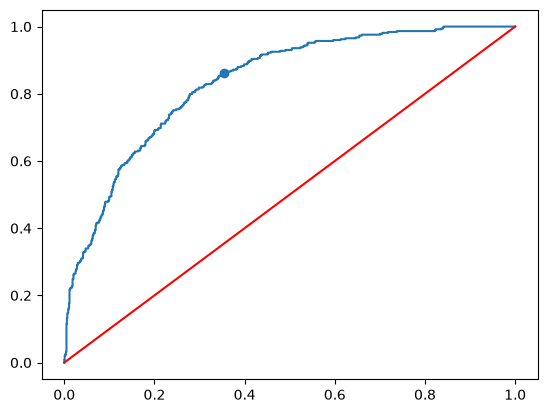

In [123]:
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])

In [70]:
tpr[idx],fpr[idx]

(np.float64(0.8074866310160428), np.float64(0.29235237173281703))

In [71]:
y_score[:,1]

array([0.01575886, 0.08391795, 0.67551969, ..., 0.05499856, 0.34410912,
       0.00500199], shape=(1407,))

In [72]:
from sklearn.metrics import classification_report

In [95]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<thresholds[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))



0.8074866310160428
0.7341862117981521
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

[[731 302]
 [ 72 302]]


In [126]:
study.best_params, thresholds[idx]

({'max_iter': 200, 'c': 1.0214844984866578}, np.float64(0.2670891332798577))

# Naive bayes investigation

In [577]:
from sklearn.naive_bayes import GaussianNB

In [160]:
nb=GaussianNB()

In [161]:
nb.fit(X_train_transformed, y_train_transformed)
y_pred=nb.predict(X_test_transformed)
y_score=nb.predict_proba(X_test_transformed)

In [162]:
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8021390374331551
0.7078891257995735
              precision    recall  f1-score   support

           0       0.90      0.67      0.77      1033
           1       0.47      0.80      0.59       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.71      0.72      1407

[[696 337]
 [ 74 300]]


In [163]:
fpr, tpr, thresholds = roc_curve(y_test_transformed, y_score[:,1])

In [459]:
idx = np.argmax(tpr-fpr)
thresholds[idx]

np.float64(0.2209701507774628)

In [460]:
idx, thresholds

(np.int64(286),
 array([       inf, 0.90734448, 0.89902384, 0.89199536, 0.87542273,
        0.8546786 , 0.84511319, 0.84475731, 0.84284286, 0.83983027,
        0.78312761, 0.78189645, 0.77422549, 0.77391926, 0.76883378,
        0.76458773, 0.76134718, 0.76079538, 0.75791308, 0.75756171,
        0.74372059, 0.74289761, 0.7380407 , 0.73720046, 0.72627261,
        0.72382647, 0.72161319, 0.72133905, 0.72083012, 0.71864409,
        0.71526507, 0.71374079, 0.701798  , 0.70071606, 0.69311587,
        0.69174835, 0.69106004, 0.68753257, 0.6815312 , 0.68096597,
        0.67894657, 0.67443671, 0.66230604, 0.65981792, 0.65872599,
        0.65805987, 0.6566542 , 0.65171078, 0.65152022, 0.65117267,
        0.64816592, 0.64514917, 0.64105738, 0.63750823, 0.63705181,
        0.63391793, 0.62561845, 0.62507924, 0.62334752, 0.62145172,
        0.62007062, 0.61272256, 0.60809734, 0.6035903 , 0.59695751,
        0.58940961, 0.58662609, 0.58612383, 0.58594829, 0.58559784,
        0.58346792, 0.57913047, 

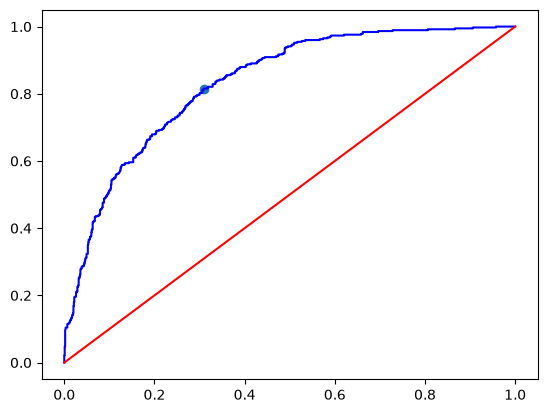

In [461]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [462]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<thresholds[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8181818181818182
0.7185501066098081
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.72      0.73      1407

[[705 328]
 [ 68 306]]


In [83]:
thresholds[idx]

np.float64(0.9351845794350055)

# knn investigation

In [84]:
from sklearn.neighbors import KNeighborsClassifier

In [92]:
def objectiveFunction(trials):
    k=trials.suggest_int("k", 3, 9, step=2)
    ls = trials.suggest_int("ls", 200, 750, step=2)

    model = KNeighborsClassifier(n_neighbors=k, leaf_size=ls)
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=10, scoring="recall").mean()


In [93]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=50)

[I 2026-09-05 18:08:41,936] A new study created in memory with name: no-name-07aa6040-76cb-46bf-96dd-6f062a03f90f
[I 2026-09-05 18:08:42,600] Trial 0 finished with value: 0.9307506053268766 and parameters: {'k': 3, 'ls': 630}. Best is trial 0 with value: 0.9307506053268766.
[I 2026-09-05 18:08:43,311] Trial 1 finished with value: 0.917191283292978 and parameters: {'k': 5, 'ls': 706}. Best is trial 0 with value: 0.9307506053268766.
[I 2026-09-05 18:08:43,938] Trial 2 finished with value: 0.917191283292978 and parameters: {'k': 5, 'ls': 614}. Best is trial 0 with value: 0.9307506053268766.
[I 2026-09-05 18:08:44,555] Trial 3 finished with value: 0.917191283292978 and parameters: {'k': 5, 'ls': 404}. Best is trial 0 with value: 0.9307506053268766.
[I 2026-09-05 18:08:45,548] Trial 4 finished with value: 0.9128329297820823 and parameters: {'k': 7, 'ls': 746}. Best is trial 0 with value: 0.9307506053268766.
[I 2026-09-05 18:08:46,250] Trial 5 finished with value: 0.9128329297820823 and para

In [96]:
study.trials_dataframe().describe()

,number,value,datetime_start,datetime_complete,duration,params_k,params_ls
count,50.00000,50.000000,50,50,50,50.000000,50.00000
mean,24.50000,0.925104,2026-09-05 18:09:09.244575488,2026-09-05 18:09:10.517330688,0 days 00:00:01.272754860,4.080000,569.72000
min,0.00000,0.912833,2026-09-05 18:08:41.939067,2026-09-05 18:08:42.600780,0 days 00:00:00.616101,3.000000,232.00000
25%,12.25000,0.917191,2026-09-05 18:08:51.325466368,2026-09-05 18:08:52.225721344,0 days 00:00:00.981932,3.000000,491.00000
50%,24.50000,0.930751,2026-09-05 18:09:08.038777088,2026-09-05 18:09:09.524404992,0 days 00:00:01.370947500,3.000000,611.00000
75%,36.75000,0.930751,2026-09-05 18:09:25.412007680,2026-09-05 18:09:27.051193344,0 days 00:00:01.490165750,5.000000,665.50000
max,49.00000,0.930751,2026-09-05 18:09:44.273271,2026-09-05 18:09:45.716681,0 days 00:00:02.075881,9.000000,750.00000
std,14.57738,0.007383,NaN,NaN,0 days 00:00:00.379431307,1.626816,131.46646


In [97]:
study.trials_dataframe().corr(numeric_only=True)

,number,value,params_k,params_ls
number,1.000000,0.297412,-0.308944,0.163771
value,0.297412,1.000000,-0.918528,0.248680
params_k,-0.308944,-0.918528,1.000000,-0.269557
params_ls,0.163771,0.248680,-0.269557,1.000000


In [98]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.93]

,number,value,datetime_start,datetime_complete,duration,params_k,params_ls,state
0,0,0.930751,2026-09-05 18:08:41.939067,2026-09-05 18:08:42.600780,0 days 00:00:00.661713,3,630,COMPLETE
8,8,0.930751,2026-09-05 18:08:47.672280,2026-09-05 18:08:48.382152,0 days 00:00:00.709872,3,686,COMPLETE
10,10,0.930751,2026-09-05 18:08:49.110984,2026-09-05 18:08:50.183981,0 days 00:00:01.072997,3,490,COMPLETE
11,11,0.930751,2026-09-05 18:08:50.184957,2026-09-05 18:08:51.105504,0 days 00:00:00.920547,3,618,COMPLETE
12,12,0.930751,2026-09-05 18:08:51.106534,2026-09-05 18:08:51.981375,0 days 00:00:00.874841,3,666,COMPLETE
13,13,0.930751,2026-09-05 18:08:51.982264,2026-09-05 18:08:52.958760,0 days 00:00:00.976496,3,544,COMPLETE
14,14,0.930751,2026-09-05 18:08:52.960567,2026-09-05 18:08:53.980558,0 days 00:00:01.019991,3,514,COMPLETE
15,15,0.930751,2026-09-05 18:08:53.982348,2026-09-05 18:08:54.961321,0 days 00:00:00.978973,3,664,COMPLETE
17,17,0.930751,2026-09-05 18:08:56.908400,2026-09-05 18:08:58.319501,0 days 00:00:01.411101,3,750,COMPLETE
19,19,0.930751,2026-09-05 18:08:59.766518,2026-09-05 18:09:01.146792,0 days 00:00:01.380274,3,676,COMPLETE


In [99]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.93].describe()

,number,value,datetime_start,datetime_complete,duration,params_k,params_ls
count,31.000000,3.100000e+01,31,31,31,31.0,31.000000
mean,27.612903,9.307506e-01,2026-09-05 18:09:13.030894848,2026-09-05 18:09:14.382914560,0 days 00:00:01.352019709,3.0,594.516129
min,0.000000,9.307506e-01,2026-09-05 18:08:41.939067,2026-09-05 18:08:42.600780,0 days 00:00:00.661713,3.0,272.000000
25%,16.000000,9.307506e-01,2026-09-05 18:08:55.445374208,2026-09-05 18:08:56.640411136,0 days 00:00:01.145743500,3.0,529.000000
50%,28.000000,9.307506e-01,2026-09-05 18:09:12.453710080,2026-09-05 18:09:13.794712064,0 days 00:00:01.408577,3.0,620.000000
75%,39.500000,9.307506e-01,2026-09-05 18:09:29.727658496,2026-09-05 18:09:31.205931008,0 days 00:00:01.529174,3.0,671.000000
max,49.000000,9.307506e-01,2026-09-05 18:09:44.273271,2026-09-05 18:09:45.716681,0 days 00:00:02.075881,3.0,750.000000
std,13.585967,4.514300e-16,NaN,NaN,0 days 00:00:00.339422406,0.0,112.799489


In [100]:
study.best_params

{'k': 3, 'ls': 630}

In [101]:
knn = KNeighborsClassifier(n_neighbors=3, leaf_size=272)
knn.fit(X_train_transformed, y_train_transformed)
y_score = knn.predict_proba(X_test_transformed)
y_pred= knn.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.6363636363636364
0.6901208244491827
              precision    recall  f1-score   support

           0       0.84      0.71      0.77      1033
           1       0.44      0.64      0.52       374

    accuracy                           0.69      1407
   macro avg       0.64      0.67      0.65      1407
weighted avg       0.74      0.69      0.70      1407

[[733 300]
 [136 238]]


In [107]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax(tpr**2-fpr)

In [108]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(3),
 np.float64(0.3333333333333333),
 np.float64(0.4365924491771539),
 np.float64(0.8288770053475936))

In [109]:
threshold

array([       inf, 1.        , 0.66666667, 0.33333333, 0.        ])

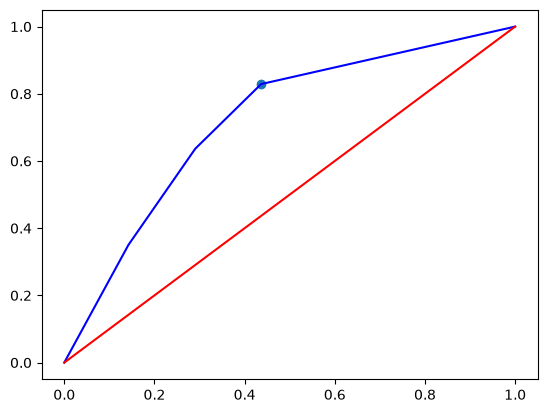

In [110]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [111]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<thresholds[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.3502673796791444
0.7228144989339019
              precision    recall  f1-score   support

           0       0.78      0.86      0.82      1033
           1       0.47      0.35      0.40       374

    accuracy                           0.72      1407
   macro avg       0.63      0.60      0.61      1407
weighted avg       0.70      0.72      0.71      1407

[[886 147]
 [243 131]]


# SVM investigation

In [112]:
from sklearn.svm import SVC

In [127]:
def objectiveFunction(trials):
    c = trials.suggest_int("degree",1,35, log=True)
    kernel = trials.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
    gamma = trials.suggest_categorical('gamma', ['scale', 'auto'])
    model = SVC(kernel=kernel , C=c, gamma=gamma)
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=2, scoring="f1").mean()


In [128]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=50)

[I 2026-09-06 14:27:42,782] A new study created in memory with name: no-name-904dc9ec-ecb5-4a59-94ee-ecaab8f1a08d
[I 2026-09-06 14:27:44,822] Trial 0 finished with value: 0.580270764897743 and parameters: {'degree': 12, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.580270764897743.
[I 2026-09-06 14:27:46,020] Trial 1 finished with value: 0.5628313284190135 and parameters: {'degree': 1, 'kernel': 'poly', 'gamma': 'scale'}. Best is trial 0 with value: 0.580270764897743.
[I 2026-09-06 14:27:47,916] Trial 2 finished with value: 0.576752932058417 and parameters: {'degree': 2, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.580270764897743.
[I 2026-09-06 14:27:49,120] Trial 3 finished with value: 0.46484766348727097 and parameters: {'degree': 4, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.580270764897743.
[I 2026-09-06 14:27:50,889] Trial 4 finished with value: 0.5847235289860317 and parameters: {'degree': 5, 'kernel': 'rbf', 'ga

In [129]:
study.trials_dataframe().describe()

,number,value,datetime_start,datetime_complete,duration,params_degree
count,50.00000,50.000000,50,50,50,50.00000
mean,24.50000,0.566351,2026-09-06 14:28:30.965093120,2026-09-06 14:28:32.939205632,0 days 00:00:01.974112160,14.20000
min,0.00000,0.462898,2026-09-06 14:27:42.788623,2026-09-06 14:27:44.822864,0 days 00:00:01.169046,1.00000
25%,12.25000,0.554669,2026-09-06 14:28:04.448399360,2026-09-06 14:28:07.392292864,0 days 00:00:01.758061500,7.25000
50%,24.50000,0.584724,2026-09-06 14:28:32.224056576,2026-09-06 14:28:34.251341056,0 days 00:00:01.902860500,13.00000
75%,36.75000,0.588848,2026-09-06 14:28:56.532744704,2026-09-06 14:28:58.533860352,0 days 00:00:02.021635750,20.00000
max,49.00000,0.590995,2026-09-06 14:29:19.696550,2026-09-06 14:29:21.569858,0 days 00:00:04.438441,35.00000
std,14.57738,0.035701,NaN,NaN,0 days 00:00:00.666141531,8.90769


In [130]:
study.trials_dataframe().corr(numeric_only=True)

,number,value,params_degree
number,1.000000,0.225622,0.318419
value,0.225622,1.000000,0.020833
params_degree,0.318419,0.020833,1.000000


In [131]:
study.best_params

{'degree': 18, 'kernel': 'rbf', 'gamma': 'scale'}

In [139]:
svc = SVC(degree=47, kernel="rbf", gamma="scale", probability=True)
svc.fit(X_train_transformed, y_train_transformed)
y_score = svc.predict_proba(X_test_transformed)
y_pred= svc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

/home/archit/Documents/chaiAurCode/100DaysOfMl/Projects/project1/myenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.47593582887700536
0.7967306325515281
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407

[[943  90]
 [196 178]]


In [144]:
svc = SVC(degree=18, kernel="rbf", gamma="scale", probability=True)
svc.fit(X_train_transformed, y_train_transformed)
y_score = svc.predict_proba(X_test_transformed)
y_pred= svc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

/home/archit/Documents/chaiAurCode/100DaysOfMl/Projects/project1/myenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.47593582887700536
0.7967306325515281
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407

[[943  90]
 [196 178]]


In [171]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax(tpr**3-fpr)

changed idx formula to get better accuracy and recall

In [172]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(300),
 np.float64(0.15000043476152303),
 np.float64(0.37947725072604066),
 np.float64(0.8368983957219251))

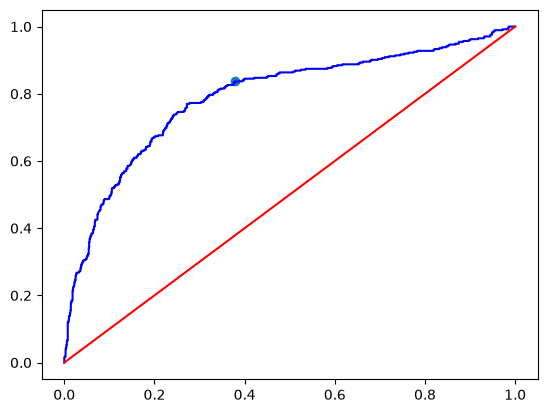

In [173]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [174]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<thresholds[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.6737967914438503
0.7604832977967306
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.67      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

[[818 215]
 [122 252]]


# Decision Tree

In [169]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
def objectiveFunction (Trials):
    criterion = Trials.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    max_depth = Trials.suggest_int("max_depth", 6, 24, step=1)
    min_samples_leaf = Trials.suggest_int("min_samples_leaf", 2, 120, step=2)
    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf
    )
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=10, scoring="recall").mean()
    

In [178]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=1000)

[I 2026-09-05 19:35:26,618] A new study created in memory with name: no-name-4a48801a-1eee-4909-9a25-50c092f3c080
[I 2026-09-05 19:35:28,223] Trial 0 finished with value: 0.8191283292978209 and parameters: {'criterion': 'log_loss', 'max_depth': 21, 'min_samples_leaf': 82}. Best is trial 0 with value: 0.8191283292978209.
[I 2026-09-05 19:35:29,692] Trial 1 finished with value: 0.809685230024213 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 68}. Best is trial 0 with value: 0.8191283292978209.
[I 2026-09-05 19:35:31,148] Trial 2 finished with value: 0.8162227602905568 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 100}. Best is trial 0 with value: 0.8191283292978209.
[I 2026-09-05 19:35:32,334] Trial 3 finished with value: 0.8070217917675546 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_leaf': 76}. Best is trial 0 with value: 0.8191283292978209.
[I 2026-09-05 19:35:33,506] Trial 4 finished with value: 0.799

In [194]:
def objectiveFunction1 (Trials):
    # criterion = Trials.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    max_depth = Trials.suggest_int("max_depth", 2, 16, step=1)
    min_samples_leaf = Trials.suggest_int("min_samples_leaf", 1, 120, step=1)
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
    )
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=10, scoring="f1").mean()
    

In [195]:
study1 = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study1.optimize(objectiveFunction1, n_trials=250)

[I 2026-09-06 14:50:02,946] A new study created in memory with name: no-name-98a12447-afd2-481d-91b9-c5a0b48bd840
[I 2026-09-06 14:50:03,945] Trial 0 finished with value: 0.5562766261529178 and parameters: {'max_depth': 12, 'min_samples_leaf': 49}. Best is trial 0 with value: 0.5562766261529178.
[I 2026-09-06 14:50:04,910] Trial 1 finished with value: 0.5525583525661941 and parameters: {'max_depth': 9, 'min_samples_leaf': 58}. Best is trial 0 with value: 0.5562766261529178.
[I 2026-09-06 14:50:05,480] Trial 2 finished with value: 0.614786147338805 and parameters: {'max_depth': 4, 'min_samples_leaf': 107}. Best is trial 2 with value: 0.614786147338805.
[I 2026-09-06 14:50:06,481] Trial 3 finished with value: 0.59565983209717 and parameters: {'max_depth': 6, 'min_samples_leaf': 35}. Best is trial 2 with value: 0.614786147338805.
[I 2026-09-06 14:50:07,120] Trial 4 finished with value: 0.5717899906862859 and parameters: {'max_depth': 12, 'min_samples_leaf': 77}. Best is trial 2 with value

In [182]:
study1.trials_dataframe().describe()

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_leaf
count,250.000000,250.000000,250,250,250,250.000000,250.000000
mean,124.500000,0.606353,2026-09-06 14:39:46.547143424,2026-09-06 14:39:47.154468352,0 days 00:00:00.607325148,5.304000,53.348000
min,0.000000,0.490285,2026-09-06 14:38:30.794980,2026-09-06 14:38:31.607293,0 days 00:00:00.312755,2.000000,1.000000
25%,62.250000,0.588032,2026-09-06 14:39:07.569994240,2026-09-06 14:39:08.176937984,0 days 00:00:00.570014500,5.000000,45.250000
50%,124.500000,0.615466,2026-09-06 14:39:46.721449984,2026-09-06 14:39:47.278941952,0 days 00:00:00.598474500,5.000000,56.000000
75%,186.750000,0.626654,2026-09-06 14:40:25.011899392,2026-09-06 14:40:25.647364608,0 days 00:00:00.636964500,5.000000,60.000000
max,249.000000,0.629285,2026-09-06 14:41:02.292460,2026-09-06 14:41:02.994124,0 days 00:00:01.237404,16.000000,120.000000
std,72.312977,0.031152,NaN,NaN,0 days 00:00:00.096844808,1.918935,24.469038


In [183]:
study1.trials_dataframe().corr(numeric_only=True)

,number,value,params_max_depth,params_min_samples_leaf
number,1.000000,0.457081,-0.167486,-0.052095
value,0.457081,1.000000,-0.236352,-0.202566
params_max_depth,-0.167486,-0.236352,1.000000,-0.059568
params_min_samples_leaf,-0.052095,-0.202566,-0.059568,1.000000


In [186]:
study1.trials_dataframe()[study1.trials_dataframe()["value"]>=0.62].describe()

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_leaf
count,121.000000,121.000000,121,121,121,121.0,121.000000
mean,160.363636,0.626869,2026-09-06 14:40:08.456369408,2026-09-06 14:40:09.069986560,0 days 00:00:00.613617016,5.0,47.545455
min,54.000000,0.622855,2026-09-06 14:39:01.851871,2026-09-06 14:39:02.439517,0 days 00:00:00.511949,5.0,1.000000
25%,115.000000,0.626003,2026-09-06 14:39:40.897918976,2026-09-06 14:39:41.494149888,0 days 00:00:00.584776,5.0,50.000000
50%,165.000000,0.626654,2026-09-06 14:40:11.291386880,2026-09-06 14:40:11.898973952,0 days 00:00:00.598540,5.0,55.000000
75%,211.000000,0.628330,2026-09-06 14:40:39.566983936,2026-09-06 14:40:40.202746112,0 days 00:00:00.619789,5.0,57.000000
max,248.000000,0.629285,2026-09-06 14:41:01.677488,2026-09-06 14:41:02.290507,0 days 00:00:00.797973,5.0,63.000000
std,57.483041,0.001597,NaN,NaN,0 days 00:00:00.047621522,0.0,17.054814


In [187]:
study1.best_params

{'criterion': 'log_loss', 'max_depth': 5, 'min_samples_leaf': 56}

In [197]:
dt=DecisionTreeClassifier(criterion="entropy", max_depth=7, min_samples_leaf=94)
dt.fit(X_train_transformed, y_train_transformed)
y_score = dt.predict_proba(X_test_transformed)
y_pred= dt.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.44385026737967914
0.7732764747690121
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.60      0.44      0.51       374

    accuracy                           0.77      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407

[[922 111]
 [208 166]]


In [201]:
dt=DecisionTreeClassifier(criterion="log_loss", max_depth=5, min_samples_leaf=56)
dt.fit(X_train_transformed, y_train_transformed)
y_score = dt.predict_proba(X_test_transformed)
y_pred= dt.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.5882352941176471
0.7761194029850746
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407

[[872 161]
 [154 220]]


In [294]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax((tpr-fpr))

In [295]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(10),
 np.float64(0.3),
 np.float64(0.25169409486931266),
 np.float64(0.7459893048128342))

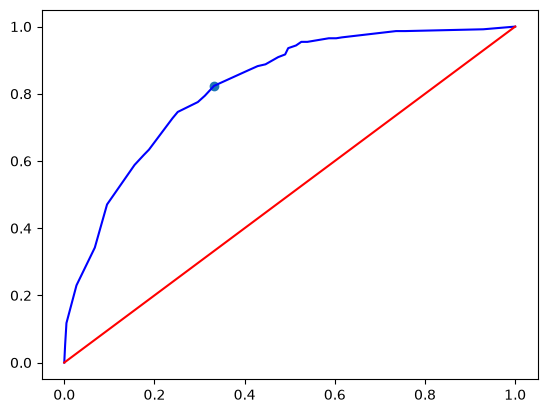

In [300]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[13], tpr[13])
plt.show()

In [297]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[13]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8235294117647058
0.7093105899076049
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1033
           1       0.47      0.82      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.75      0.69      1407
weighted avg       0.80      0.71      0.73      1407

[[690 343]
 [ 66 308]]


# Random Forest Classifier

In [298]:
from sklearn.ensemble import RandomForestClassifier

In [302]:
def objectiveFunction(Trials):
    n_estimators = Trials.suggest_int("n_estimators", 100, 900, step=10)
    criterion = Trials.suggest_categorical("criterion", ["gini", "entropy"])
    max_depth = Trials.suggest_int("max_depth", 1, 16, step=1)
    min_samples_leaf = Trials.suggest_int("min_samples_leaf", 2, 110, step=2)
    bootstrap=False
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap,
        n_jobs=-1,
        random_state=42
    )
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=5, scoring="f1").mean()


In [303]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=50)

[I 2026-09-06 15:16:23,076] A new study created in memory with name: no-name-db62fd34-bcb3-4a90-ba03-05dec7dcc6e0
[I 2026-09-06 15:17:01,844] Trial 0 finished with value: 0.5880004689596194 and parameters: {'n_estimators': 890, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 22}. Best is trial 0 with value: 0.5880004689596194.
[I 2026-09-06 15:17:13,296] Trial 1 finished with value: 0.5550992674487356 and parameters: {'n_estimators': 320, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 16}. Best is trial 0 with value: 0.5880004689596194.
[I 2026-09-06 15:17:27,828] Trial 2 finished with value: 0.574409201196828 and parameters: {'n_estimators': 310, 'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 72}. Best is trial 0 with value: 0.5880004689596194.
[I 2026-09-06 15:17:37,384] Trial 3 finished with value: 0.5805011488688108 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 24}. Best is trial 0 with value:

In [304]:
study.trials_dataframe().describe()

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_leaf,params_n_estimators
count,50.00000,50.000000,50,50,50,50.000000,50.000000,50.000000
mean,24.50000,0.563396,2026-09-06 15:24:59.483336448,2026-09-06 15:25:22.526172928,0 days 00:00:23.042836660,9.060000,26.960000,640.800000
min,0.00000,0.000000,2026-09-06 15:16:23.081417,2026-09-06 15:17:01.843906,0 days 00:00:04.290026,1.000000,2.000000,120.000000
25%,12.25000,0.570700,2026-09-06 15:19:50.523407104,2026-09-06 15:20:21.915163904,0 days 00:00:18.695965250,7.250000,8.000000,545.000000
50%,24.50000,0.579913,2026-09-06 15:24:29.228423168,2026-09-06 15:25:00.071636480,0 days 00:00:23.034863,9.000000,17.000000,690.000000
75%,36.75000,0.586742,2026-09-06 15:29:45.177093888,2026-09-06 15:30:17.278533632,0 days 00:00:28.258990500,11.000000,32.000000,800.000000
max,49.00000,0.590844,2026-09-06 15:35:21.768319,2026-09-06 15:35:35.298341,0 days 00:00:40.425667,16.000000,110.000000,900.000000
std,14.57738,0.084279,NaN,NaN,0 days 00:00:08.174409690,3.139024,28.003615,207.392362


In [305]:
study.trials_dataframe().corr(numeric_only=True)

,number,value,params_max_depth,params_min_samples_leaf,params_n_estimators
number,1.000000,0.231048,0.029659,-0.350852,0.417447
value,0.231048,1.000000,0.501406,-0.085929,-0.058755
params_max_depth,0.029659,0.501406,1.000000,0.057372,-0.282839
params_min_samples_leaf,-0.350852,-0.085929,0.057372,1.000000,-0.334805
params_n_estimators,0.417447,-0.058755,-0.282839,-0.334805,1.000000


In [306]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.585]

,number,value,datetime_start,datetime_complete,duration,params_criterion,params_max_depth,params_min_samples_leaf,params_n_estimators,state
0,0,0.588000,2026-09-06 15:16:23.081417,2026-09-06 15:17:01.843906,0 days 00:00:38.762489,entropy,10,22,890,COMPLETE
16,16,0.589144,2026-09-06 15:20:56.785642,2026-09-06 15:21:25.093683,0 days 00:00:28.308041,entropy,9,2,700,COMPLETE
17,17,0.587431,2026-09-06 15:21:25.094618,2026-09-06 15:21:52.228262,0 days 00:00:27.133644,entropy,8,2,730,COMPLETE
19,19,0.587587,2026-09-06 15:22:19.948802,2026-09-06 15:22:46.753171,0 days 00:00:26.804369,entropy,9,2,690,COMPLETE
21,21,0.590844,2026-09-06 15:23:08.657475,2026-09-06 15:23:33.250215,0 days 00:00:24.592740,entropy,9,8,640,COMPLETE
23,23,0.586474,2026-09-06 15:23:54.425360,2026-09-06 15:24:13.970248,0 days 00:00:19.544888,entropy,10,14,510,COMPLETE
24,24,0.585196,2026-09-06 15:24:13.972308,2026-09-06 15:24:44.483578,0 days 00:00:30.511270,entropy,13,10,730,COMPLETE
25,25,0.586406,2026-09-06 15:24:44.484538,2026-09-06 15:25:15.659695,0 days 00:00:31.175157,entropy,10,22,840,COMPLETE
27,27,0.590621,2026-09-06 15:25:36.988918,2026-09-06 15:26:05.100757,0 days 00:00:28.111839,entropy,9,8,730,COMPLETE
31,31,0.585727,2026-09-06 15:27:08.311120,2026-09-06 15:27:39.716515,0 days 00:00:31.405395,entropy,9,18,860,COMPLETE


In [307]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.59]

,number,value,datetime_start,datetime_complete,duration,params_criterion,params_max_depth,params_min_samples_leaf,params_n_estimators,state
21,21,0.590844,2026-09-06 15:23:08.657475,2026-09-06 15:23:33.250215,0 days 00:00:24.592740,entropy,9,8,640,COMPLETE
27,27,0.590621,2026-09-06 15:25:36.988918,2026-09-06 15:26:05.100757,0 days 00:00:28.111839,entropy,9,8,730,COMPLETE


In [309]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.59].describe()

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_leaf,params_n_estimators
count,2.000000,2.000000,2,2,2,2.0,2.0,2.00000
mean,24.000000,0.590732,2026-09-06 15:24:22.823196672,2026-09-06 15:24:49.175485952,0 days 00:00:26.352289500,9.0,8.0,685.00000
min,21.000000,0.590621,2026-09-06 15:23:08.657475,2026-09-06 15:23:33.250215,0 days 00:00:24.592740,9.0,8.0,640.00000
25%,22.500000,0.590676,2026-09-06 15:23:45.740335872,2026-09-06 15:24:11.212850432,0 days 00:00:25.472514750,9.0,8.0,662.50000
50%,24.000000,0.590732,2026-09-06 15:24:22.823196416,2026-09-06 15:24:49.175485952,0 days 00:00:26.352289500,9.0,8.0,685.00000
75%,25.500000,0.590788,2026-09-06 15:24:59.906057216,2026-09-06 15:25:27.138121472,0 days 00:00:27.232064250,9.0,8.0,707.50000
max,27.000000,0.590844,2026-09-06 15:25:36.988918,2026-09-06 15:26:05.100757,0 days 00:00:28.111839,9.0,8.0,730.00000
std,4.242641,0.000158,NaN,NaN,0 days 00:00:02.488378766,0.0,0.0,63.63961


In [274]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.585].corr(numeric_only=True)

,number,value,params_max_depth,params_min_samples_leaf,params_n_estimators
number,1.000000,0.452460,-0.463366,-0.337074,-0.117506
value,0.452460,1.000000,-0.145923,-0.144949,-0.435466
params_max_depth,-0.463366,-0.145923,1.000000,0.613457,0.323962
params_min_samples_leaf,-0.337074,-0.144949,0.613457,1.000000,0.470888
params_n_estimators,-0.117506,-0.435466,0.323962,0.470888,1.000000


In [310]:
study.best_params

{'n_estimators': 640,
 'criterion': 'entropy',
 'max_depth': 9,
 'min_samples_leaf': 8}

In [321]:
rfc = RandomForestClassifier(n_estimators=142, criterion="entropy", max_depth=13, min_samples_leaf=2, bootstrap=False, n_jobs=-1)
rfc.fit(X_train_transformed, y_train_transformed)
y_score = rfc.predict_proba(X_test_transformed)
y_pred = rfc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.49732620320855614
0.7860696517412935
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407

[[920 113]
 [188 186]]


In [316]:
rfc = RandomForestClassifier(n_estimators=640, criterion="entropy", max_depth=9, min_samples_leaf=8, bootstrap=False, n_jobs=-1)
rfc.fit(X_train_transformed, y_train_transformed)
y_score = rfc.predict_proba(X_test_transformed)
y_pred = rfc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.48128342245989303
0.7896233120113717
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[931 102]
 [194 180]]


In [322]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr-threshold**4)

In [323]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(305),
 np.float64(0.23898160775340246),
 np.float64(0.3194578896418199),
 np.float64(0.8315508021390374))

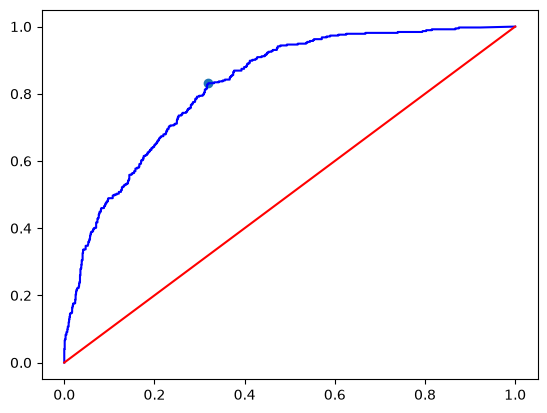

In [324]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [325]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8315508021390374
0.720682302771855
              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1033
           1       0.49      0.83      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[703 330]
 [ 63 311]]


# adaptive Boosting

In [326]:
from sklearn.ensemble import AdaBoostClassifier

In [332]:
def objectiveFunction(Trials):
    n_estimators = Trials.suggest_int("n_estimators", 10, 750, step=5)
    learning_rate = Trials.suggest_float("learning_rate", 0.001, 5, step=0.001)
    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42
    )
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=5, scoring="f1").mean()


In [333]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=20)

[I 2026-09-06 15:41:33,071] A new study created in memory with name: no-name-0925b201-3077-4689-846d-18e0e1d08846
[I 2026-09-06 15:42:16,435] Trial 0 finished with value: 0.5966184662010722 and parameters: {'n_estimators': 595, 'learning_rate': 1.28}. Best is trial 0 with value: 0.5966184662010722.
[I 2026-09-06 15:42:45,459] Trial 1 finished with value: 0.6010945764092529 and parameters: {'n_estimators': 405, 'learning_rate': 1.259}. Best is trial 1 with value: 0.6010945764092529.
[I 2026-09-06 15:43:29,400] Trial 2 finished with value: 0.0012698412698412698 and parameters: {'n_estimators': 600, 'learning_rate': 2.9}. Best is trial 1 with value: 0.6010945764092529.
[I 2026-09-06 15:44:05,707] Trial 3 finished with value: 0.008556149732620321 and parameters: {'n_estimators': 485, 'learning_rate': 3.557}. Best is trial 1 with value: 0.6010945764092529.
[I 2026-09-06 15:44:49,667] Trial 4 finished with value: 0.015500594177064763 and parameters: {'n_estimators': 585, 'learning_rate': 3.4

In [334]:
study.trials_dataframe().describe()

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_n_estimators
count,20.00000,20.000000,20,20,20,20.000000,20.000000
mean,9.50000,0.329579,2026-09-06 15:46:58.385974528,2026-09-06 15:47:31.796432640,0 days 00:00:33.410458200,2.143100,442.500000
min,0.00000,0.000000,2026-09-06 15:41:33.073386,2026-09-06 15:42:16.434945,0 days 00:00:01.197876,0.009000,15.000000
25%,4.75000,0.006735,2026-09-06 15:44:38.679442432,2026-09-06 15:45:04.667083520,0 days 00:00:24.571039250,1.198000,333.750000
50%,9.50000,0.561043,2026-09-06 15:46:53.617409536,2026-09-06 15:47:21.360575232,0 days 00:00:34.655945,1.826500,447.500000
75%,14.25000,0.589022,2026-09-06 15:49:31.396270592,2026-09-06 15:50:19.296260096,0 days 00:00:43.944270750,3.293000,596.250000
max,19.00000,0.601708,2026-09-06 15:52:15.223148,2026-09-06 15:52:41.318661,0 days 00:00:59.401481,4.869000,750.000000
std,5.91608,0.291813,NaN,NaN,0 days 00:00:16.211208305,1.373419,217.076872


In [335]:
study.trials_dataframe().corr(numeric_only=True)

,number,value,params_learning_rate,params_n_estimators
number,1.000000,0.127819,-0.154625,-0.120079
value,0.127819,1.000000,-0.695703,0.161011
params_learning_rate,-0.154625,-0.695703,1.000000,-0.229910
params_n_estimators,-0.120079,0.161011,-0.229910,1.000000


In [336]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.6].corr(numeric_only=True)

,number,value,params_learning_rate,params_n_estimators
number,1.0,1.0,1.0,1.0
value,1.0,1.0,1.0,1.0
params_learning_rate,1.0,1.0,1.0,1.0
params_n_estimators,1.0,1.0,1.0,1.0


In [337]:
study.best_params

{'n_estimators': 750, 'learning_rate': 1.388}

In [338]:
abc=AdaBoostClassifier(n_estimators=150, learning_rate=0.886)
abc.fit(X_train_transformed, y_train_transformed)
y_score = abc.predict_proba(X_test_transformed)
y_pred = abc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.5053475935828877
0.7910447761194029
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[924 109]
 [185 189]]


In [ ]:
abc=AdaBoostClassifier(n_estimators=750, learning_rate=1.388)
abc.fit(X_train_transformed, y_train_transformed)
y_score = abc.predict_proba(X_test_transformed)
y_pred = abc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.6737967914438503
0.7626154939587776
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.67      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.76      0.77      1407

[[821 212]
 [122 252]]


In [455]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax((tpr-fpr))

In [456]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(286),
 np.float64(0.22800291871977138),
 np.float64(0.30880929332042595),
 np.float64(0.8155080213903744))

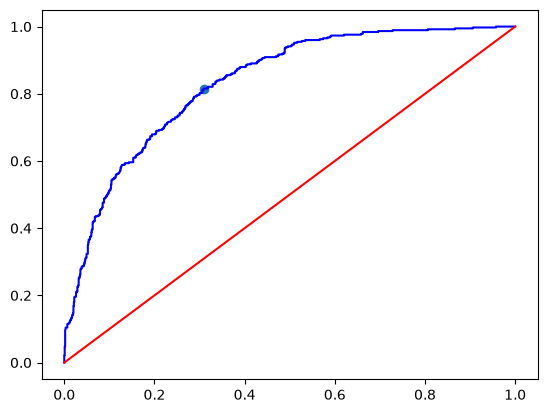

In [457]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [458]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8155080213903744
0.7242359630419332
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[714 319]
 [ 69 305]]


In [424]:
study.best_params, threshold[idx]

({'n_estimators': 750, 'learning_rate': 1.388}, np.float64(0.4266060261245185))

# Gradient Boosting

In [425]:
from sklearn.ensemble import GradientBoostingClassifier

In [436]:
def objectiveFunction(Trials):
    n_estimators = Trials.suggest_int("n_estimators", 350, 900, step=5)
    learning_rate = Trials.suggest_float("learning_rate", 0.001, 0.5, step=0.001)
    min_samples_leaf = Trials.suggest_int("min_samples_leaf", 74, 150, step=2)
    loss = Trials.suggest_categorical("loss", ["log_loss", "exponential"])

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42,
        min_samples_leaf=min_samples_leaf,
        loss=loss
    )
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=2, scoring="f1").mean()


In [437]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=50)

[I 2026-09-06 16:58:57,218] A new study created in memory with name: no-name-61e09a70-8b21-477d-8e2e-99ffb7873118
[I 2026-09-06 16:59:12,660] Trial 0 finished with value: 0.5574699979659639 and parameters: {'n_estimators': 520, 'learning_rate': 0.375, 'min_samples_leaf': 104, 'loss': 'exponential'}. Best is trial 0 with value: 0.5574699979659639.
[I 2026-09-06 16:59:39,509] Trial 1 finished with value: 0.5772943149805944 and parameters: {'n_estimators': 890, 'learning_rate': 0.024, 'min_samples_leaf': 126, 'loss': 'log_loss'}. Best is trial 1 with value: 0.5772943149805944.
[I 2026-09-06 16:59:53,795] Trial 2 finished with value: 0.5732690493267534 and parameters: {'n_estimators': 465, 'learning_rate': 0.094, 'min_samples_leaf': 98, 'loss': 'log_loss'}. Best is trial 1 with value: 0.5772943149805944.
[I 2026-09-06 17:00:11,890] Trial 3 finished with value: 0.5876726248060304 and parameters: {'n_estimators': 540, 'learning_rate': 0.036000000000000004, 'min_samples_leaf': 116, 'loss': 'e

In [438]:
study.trials_dataframe()[study.trials_dataframe()["value"]>0.585]

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_loss,params_min_samples_leaf,params_n_estimators,state
3,3,0.587673,2026-09-06 16:59:53.797229,2026-09-06 17:00:11.890354,0 days 00:00:18.093125,0.036,exponential,116,540,COMPLETE
15,15,0.587008,2026-09-06 17:03:45.114681,2026-09-06 17:03:56.054804,0 days 00:00:10.940123,0.067,exponential,116,355,COMPLETE
16,16,0.586560,2026-09-06 17:03:56.056620,2026-09-06 17:04:09.727120,0 days 00:00:13.670500,0.053,exponential,120,440,COMPLETE
21,21,0.585353,2026-09-06 17:05:05.606561,2026-09-06 17:05:19.043333,0 days 00:00:13.436772,0.057,exponential,122,450,COMPLETE
22,22,0.585600,2026-09-06 17:05:19.044635,2026-09-06 17:05:31.565060,0 days 00:00:12.520425,0.072,exponential,114,410,COMPLETE
24,24,0.589796,2026-09-06 17:05:46.365327,2026-09-06 17:05:59.346510,0 days 00:00:12.981183,0.040,exponential,124,435,COMPLETE
25,25,0.589719,2026-09-06 17:05:59.347664,2026-09-06 17:06:16.824418,0 days 00:00:17.476754,0.040,exponential,130,565,COMPLETE
26,26,0.589023,2026-09-06 17:06:16.825433,2026-09-06 17:06:32.840811,0 days 00:00:16.015378,0.021,log_loss,136,530,COMPLETE
31,31,0.586608,2026-09-06 17:07:41.725853,2026-09-06 17:07:57.950766,0 days 00:00:16.224913,0.035,exponential,126,540,COMPLETE
34,34,0.588655,2026-09-06 17:08:30.753905,2026-09-06 17:08:47.322797,0 days 00:00:16.568892,0.030,exponential,124,540,COMPLETE


In [439]:
study.trials_dataframe()[study.trials_dataframe()["value"]>0.585].corr(numeric_only=True)

,number,value,params_learning_rate,params_min_samples_leaf,params_n_estimators
number,1.000000,0.553044,0.012714,0.806871,0.125396
value,0.553044,1.000000,-0.223565,0.556537,0.003857
params_learning_rate,0.012714,-0.223565,1.000000,-0.307942,-0.480545
params_min_samples_leaf,0.806871,0.556537,-0.307942,1.000000,0.461000
params_n_estimators,0.125396,0.003857,-0.480545,0.461000,1.000000


In [441]:
study.trials_dataframe()[study.trials_dataframe()["value"]>0.585].describe()

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_min_samples_leaf,params_n_estimators
count,19.000000,19.000000,19,19,19,19.000000,19.00000,19.000000
mean,30.789474,0.588696,2026-09-06 17:07:40.395134976,2026-09-06 17:07:55.556805376,0 days 00:00:15.161670052,0.046474,128.00000,492.894737
min,3.000000,0.585353,2026-09-06 16:59:53.797229,2026-09-06 17:00:11.890354,0 days 00:00:10.940123,0.017000,114.00000,355.000000
25%,23.000000,0.586976,2026-09-06 17:05:32.704980992,2026-09-06 17:05:45.455784960,0 days 00:00:13.288709500,0.032000,123.00000,437.500000
50%,34.000000,0.588078,2026-09-06 17:08:30.753904896,2026-09-06 17:08:47.322797056,0 days 00:00:14.992401,0.040000,130.00000,480.000000
75%,40.500000,0.589758,2026-09-06 17:10:23.752811264,2026-09-06 17:10:38.479168,0 days 00:00:16.120145500,0.058500,134.00000,535.000000
max,48.000000,0.593262,2026-09-06 17:12:10.425672,2026-09-06 17:12:26.044338,0 days 00:00:25.400008,0.082000,140.00000,840.000000
std,12.021180,0.002275,NaN,NaN,0 days 00:00:03.097690728,0.018863,8.11035,101.040638


In [442]:
study.best_params

{'n_estimators': 480,
 'learning_rate': 0.059000000000000004,
 'min_samples_leaf': 134,
 'loss': 'exponential'}

In [444]:
gb = GradientBoostingClassifier(
        n_estimators=480,
        learning_rate=0.059000000000000004,
        min_samples_leaf=134,
        loss="log_loss"
    )

gb.fit(X_train_transformed, y_train_transformed)
y_score = gb.predict_proba(X_test_transformed)
y_pred = gb.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.5106951871657754
0.7967306325515281
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

[[930 103]
 [183 191]]


In [451]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax((tpr-fpr))

In [452]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(286),
 np.float64(0.22800291871977138),
 np.float64(0.30880929332042595),
 np.float64(0.8155080213903744))

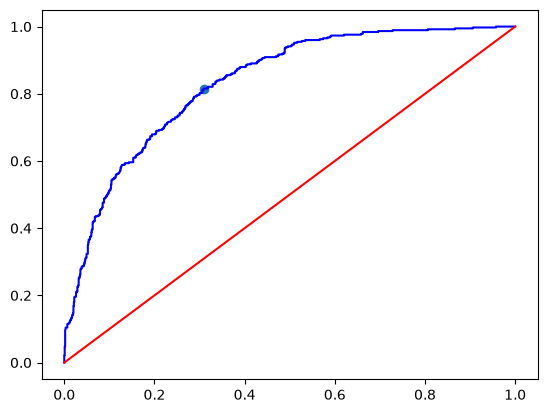

In [ ]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [454]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8155080213903744
0.7242359630419332
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[714 319]
 [ 69 305]]


# XGboost investigation


In [464]:
import xgboost as xgb

In [531]:
def objectiveFunction(Trials):
    objective = "binary:logistic"
    n_estimators = Trials.suggest_int("n_estimators", 140, 900, step=5)
    learning_rate = Trials.suggest_float("learning_rate", 0.001, 1, step=0.001)
    alpha = Trials.suggest_float("alpha", 10, 25, step=1)
    
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42,
        objective=objective,
        alpha=alpha
    )
    return cross_val_score(model, X_train_transformed, y_train_transformed, cv=5, scoring="f1").mean()


In [532]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objectiveFunction, n_trials=50)

[I 2026-09-06 21:53:55,036] A new study created in memory with name: no-name-5f3fd577-65d9-4546-b98a-c3ba1728c968
[I 2026-09-06 21:54:02,562] Trial 0 finished with value: 0.6013160859816138 and parameters: {'n_estimators': 860, 'learning_rate': 0.962, 'alpha': 17.0}. Best is trial 0 with value: 0.6013160859816138.
[I 2026-09-06 21:54:13,336] Trial 1 finished with value: 0.5948921721138597 and parameters: {'n_estimators': 340, 'learning_rate': 0.026000000000000002, 'alpha': 24.0}. Best is trial 0 with value: 0.6013160859816138.
[I 2026-09-06 21:54:20,953] Trial 2 finished with value: 0.5995552773103021 and parameters: {'n_estimators': 710, 'learning_rate': 0.14200000000000002, 'alpha': 22.0}. Best is trial 0 with value: 0.6013160859816138.
[I 2026-09-06 21:54:27,461] Trial 3 finished with value: 0.5959179775166371 and parameters: {'n_estimators': 745, 'learning_rate': 0.40700000000000003, 'alpha': 12.0}. Best is trial 0 with value: 0.6013160859816138.
[I 2026-09-06 21:54:31,751] Trial 4

In [533]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_learning_rate,params_n_estimators,state
0,0,0.601316,2026-09-06 21:53:55.041207,2026-09-06 21:54:02.561931,0 days 00:00:07.520724,17.0,0.962,860,COMPLETE
1,1,0.594892,2026-09-06 21:54:02.564819,2026-09-06 21:54:13.336162,0 days 00:00:10.771343,24.0,0.026,340,COMPLETE
2,2,0.599555,2026-09-06 21:54:13.338296,2026-09-06 21:54:20.953850,0 days 00:00:07.615554,22.0,0.142,710,COMPLETE
3,3,0.595918,2026-09-06 21:54:20.955508,2026-09-06 21:54:27.461661,0 days 00:00:06.506153,12.0,0.407,745,COMPLETE
4,4,0.593226,2026-09-06 21:54:27.463310,2026-09-06 21:54:31.751286,0 days 00:00:04.287976,11.0,0.973,465,COMPLETE
5,5,0.599766,2026-09-06 21:54:31.754142,2026-09-06 21:54:34.951632,0 days 00:00:03.197490,10.0,0.691,340,COMPLETE
6,6,0.594765,2026-09-06 21:54:34.954246,2026-09-06 21:54:44.737209,0 days 00:00:09.782963,22.0,0.041,805,COMPLETE
7,7,0.589038,2026-09-06 21:54:44.739543,2026-09-06 21:54:48.963469,0 days 00:00:04.223926,17.0,0.665,610,COMPLETE
8,8,0.596302,2026-09-06 21:54:48.965734,2026-09-06 21:54:53.378151,0 days 00:00:04.412417,22.0,0.792,535,COMPLETE
9,9,0.603278,2026-09-06 21:54:53.381072,2026-09-06 21:54:58.515799,0 days 00:00:05.134727,13.0,0.736,780,COMPLETE


In [534]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.599]

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_learning_rate,params_n_estimators,state
0,0,0.601316,2026-09-06 21:53:55.041207,2026-09-06 21:54:02.561931,0 days 00:00:07.520724,17.0,0.962,860,COMPLETE
2,2,0.599555,2026-09-06 21:54:13.338296,2026-09-06 21:54:20.953850,0 days 00:00:07.615554,22.0,0.142,710,COMPLETE
5,5,0.599766,2026-09-06 21:54:31.754142,2026-09-06 21:54:34.951632,0 days 00:00:03.197490,10.0,0.691,340,COMPLETE
9,9,0.603278,2026-09-06 21:54:53.381072,2026-09-06 21:54:58.515799,0 days 00:00:05.134727,13.0,0.736,780,COMPLETE
11,11,0.604324,2026-09-06 21:55:00.538615,2026-09-06 21:55:06.728893,0 days 00:00:06.190278,17.0,0.932,900,COMPLETE
12,12,0.602648,2026-09-06 21:55:06.731551,2026-09-06 21:55:13.130350,0 days 00:00:06.398799,14.0,0.778,870,COMPLETE
13,13,0.600910,2026-09-06 21:55:13.134829,2026-09-06 21:55:18.818867,0 days 00:00:05.684038,18.0,0.586,690,COMPLETE
14,14,0.600239,2026-09-06 21:55:18.820786,2026-09-06 21:55:26.309138,0 days 00:00:07.488352,14.0,0.865,895,COMPLETE
15,15,0.603039,2026-09-06 21:55:26.313489,2026-09-06 21:55:32.312280,0 days 00:00:05.998791,19.0,0.503,770,COMPLETE
17,17,0.601661,2026-09-06 21:55:37.335415,2026-09-06 21:55:44.190542,0 days 00:00:06.855127,16.0,0.992,805,COMPLETE


In [538]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.605].describe()

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_learning_rate,params_n_estimators
count,6.000000,6.000000,6,6,6,6.000000,6.000000,6.000000
mean,37.333333,0.607308,2026-09-06 21:57:24.871552768,2026-09-06 21:57:30.193487616,0 days 00:00:05.321934666,20.000000,0.832500,697.500000
min,22.000000,0.605253,2026-09-06 21:56:06.701176,2026-09-06 21:56:12.675307,0 days 00:00:04.786481,19.000000,0.826000,660.000000
25%,32.750000,0.606355,2026-09-06 21:57:06.129406208,2026-09-06 21:57:10.954996224,0 days 00:00:05.046858,20.000000,0.827250,683.750000
50%,41.500000,0.607171,2026-09-06 21:57:44.202317824,2026-09-06 21:57:49.398667776,0 days 00:00:05.389148,20.000000,0.829000,695.000000
75%,43.500000,0.607943,2026-09-06 21:57:54.605901568,2026-09-06 21:57:59.987355648,0 days 00:00:05.442241,20.000000,0.837500,702.500000
max,45.000000,0.609969,2026-09-06 21:58:02.611307,2026-09-06 21:58:08.030925,0 days 00:00:05.974131,21.000000,0.844000,750.000000
std,9.244818,0.001648,NaN,NaN,0 days 00:00:00.420228834,0.632456,0.007583,30.124741


In [539]:
study.trials_dataframe()[study.trials_dataframe()["value"]>=0.605].corr(numeric_only=True)

,number,value,params_alpha,params_learning_rate,params_n_estimators
number,1.000000,0.711117,0.786737,-0.941481,-0.585283
value,0.711117,1.000000,0.359762,-0.847940,-0.761062
params_alpha,0.786737,0.359762,1.000000,-0.583840,-0.577350
params_learning_rate,-0.941481,-0.847940,-0.583840,1.000000,0.606307
params_n_estimators,-0.585283,-0.761062,-0.577350,0.606307,1.000000


In [540]:
study.best_params

{'n_estimators': 660, 'learning_rate': 0.8260000000000001, 'alpha': 20.0}

In [541]:
xgbmodel=xgb.XGBClassifier(objective="binary:logistic", n_estimators=660, learning_rate=0.8260000000000001, alpha=20.0)
xgbmodel.fit(X_train_transformed, y_train_transformed)
y_score = xgbmodel.predict_proba(X_test_transformed)
y_pred = xgbmodel.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.5080213903743316
0.7924662402274343
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[925 108]
 [184 190]]


In [572]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax((tpr-fpr))

In [573]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(261),
 np.float64(0.2956359386444092),
 np.float64(0.2362052274927396),
 np.float64(0.7379679144385026))

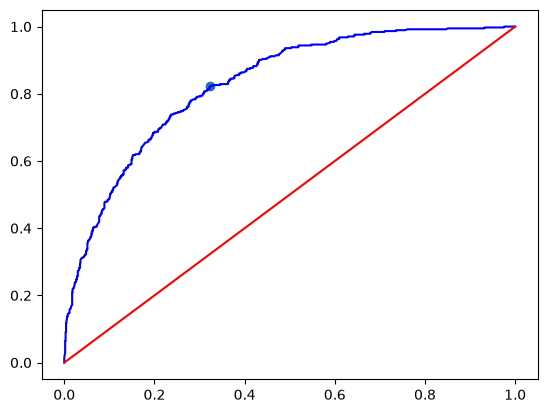

In [570]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [574]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.7379679144385026
0.7569296375266524
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407

[[789 244]
 [ 98 276]]


- logistic base
``` 
0.4679144385026738
0.7867803837953091
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

[[932 101]
 [199 175]] 
```
- logistic adjusted
```
0.8074866310160428
0.7341862117981521
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

[[731 302]
 [ 72 302]]
```
- naive bayes base
```
0.8021390374331551
0.7078891257995735
              precision    recall  f1-score   support

           0       0.90      0.67      0.77      1033
           1       0.47      0.80      0.59       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.71      0.72      1407

[[696 337]
 [ 74 300]]
```

- naive bayes adjusted
```
0.8181818181818182
0.7185501066098081
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.72      0.73      1407

[[705 328]
 [ 68 306]]
```

- knn
```
0.6363636363636364
0.6901208244491827
              precision    recall  f1-score   support

           0       0.84      0.71      0.77      1033
           1       0.44      0.64      0.52       374

    accuracy                           0.69      1407
   macro avg       0.64      0.67      0.65      1407
weighted avg       0.74      0.69      0.70      1407

[[733 300]
 [136 238]]
```

- svm
```
0.6737967914438503
0.7604832977967306
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.67      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

[[818 215]
 [122 252]]
```

- DT base
```
0.5882352941176471
0.7761194029850746
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407

[[872 161]
 [154 220]]
```

- DT adjusted
```
0.8235294117647058
0.7093105899076049
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1033
           1       0.47      0.82      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.75      0.69      1407
weighted avg       0.80      0.71      0.73      1407

[[690 343]
 [ 66 308]]
```

- rfc base
```
0.48128342245989303
0.7896233120113717
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[931 102]
 [194 180]]
```

- rfc adjusted

```
0.8315508021390374
0.720682302771855
              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1033
           1       0.49      0.83      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[703 330]
 [ 63 311]]
```

- adaboost base

```
0.6737967914438503
0.7626154939587776
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.67      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.76      0.77      1407

[[821 212]
 [122 252]]
```

- adaboost adjusted

```
0.8155080213903744
0.7242359630419332
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[714 319]
 [ 69 305]]
```

- GB base

```
0.5106951871657754
0.7967306325515281
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

[[930 103]
 [183 191]]
```

- GB adjusted
```
0.8155080213903744
0.7242359630419332
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[714 319]
 [ 69 305]]
```

- XgBOost base
```
0.5080213903743316
0.7924662402274343
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[925 108]
 [184 190]]
```

-XgBoost adjusted
```
0.7379679144385026
0.7569296375266524
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407

[[789 244]
 [ 98 276]]
```

# stacking

In [575]:
from sklearn.ensemble import StackingClassifier


In [579]:
stc = StackingClassifier(
    estimators= [
        ("ada",AdaBoostClassifier(n_estimators=750, learning_rate=1.388)),
        ("Naive", GaussianNB()),
        ("rfc", RandomForestClassifier(n_estimators=640, criterion="entropy", max_depth=9, min_samples_leaf=8, bootstrap=False)),
        ("xgb", xgb.XGBClassifier(objective="binary:logistic", n_estimators=660, learning_rate=0.8260000000000001, alpha=20.0)),
        ("gb", GradientBoostingClassifier(n_estimators=480, learning_rate=0.059000000000000004, min_samples_leaf=134, loss="log_loss"))
    ], 
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

In [580]:
stc.fit(X_train_transformed, y_train_transformed)
y_score = stc.predict_proba(X_test_transformed)
y_pred = stc.predict(X_test_transformed)

print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.02s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.02s - Debugger warning: It seems that frozen modules are being used, which may
0

0.5133689839572193
0.8017057569296375
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

[[936  97]
 [182 192]]


In [601]:
fpr, tpr, threshold = roc_curve(y_test_transformed, y_score[:,1])
idx=np.argmax((tpr-fpr))

In [602]:
idx, threshold[idx], fpr[idx], tpr[idx]

(np.int64(274),
 np.float64(0.2119762196374347),
 np.float64(0.2836398838334947),
 np.float64(0.8074866310160428))

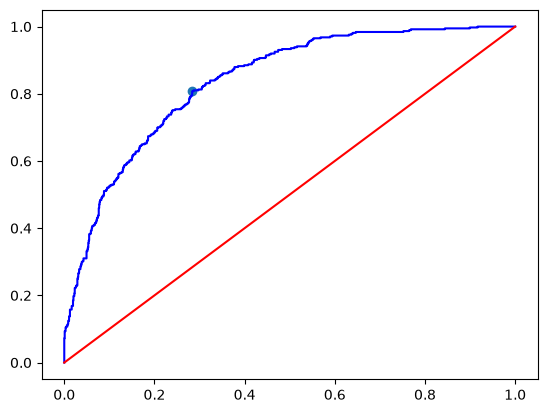

In [603]:
plt.plot(fpr,tpr, color="blue")
plt.plot([0,1],[0,1], color="red")
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [604]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y_test_transformed, y_pred))
print(accuracy_score(y_test_transformed, y_pred))
print(classification_report(y_test_transformed, y_pred))
print(confusion_matrix(y_test_transformed, y_pred))

0.8074866310160428
0.7405828002842928
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

[[740 293]
 [ 72 302]]


# Adding total charges

In [35]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X1 = df.iloc[:, :-1]
y1 = df.iloc[:, -1]

In [39]:
y1

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: object

In [40]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, random_state=42, test_size=0.2
)

In [41]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.pipeline import Pipeline


In [42]:
featureResembling1= ColumnTransformer(
    [
        ("ohe", OneHotEncoder(sparse_output=False), ["InternetService", "gender", "PaymentMethod", "Contract"]),
        (
            "oeYn", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[yn]*4)),
                ("scaler", MinMaxScaler()),
            ]
            ), 
            ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
            ),
        (
            "oeYnn", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[ynn])),
                ("scaler", MinMaxScaler())
            ]
            ), 
            ["MultipleLines"]
            ),
        (
            "oeYnn1", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[ynn1]*6)),
                ("scaler", MinMaxScaler())
            ]
            ) 
            ,["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
            ),
        ("stdScaling", Pipeline(
            [
                ("poly", PolynomialFeatures(degree=3)),
                ("scaling",StandardScaler())
                ]
            ), ["tenure", "MonthlyCharges", "TotalCharges"])
        ], remainder="passthrough"
)

In [43]:
X1_train_transformed=featureResembling1.fit_transform(X1_train)
X1_test_transformed=featureResembling1.transform(X1_test)

In [44]:
le = LabelEncoder()
y1_train_transformed = le.fit_transform(y1_train)
y1_test_transformed = le.transform(y1_test)

In [45]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [46]:
from imblearn.over_sampling import SMOTE

In [47]:
smote = SMOTE()
X1_train_transformed, y1_train_transformed = smote.fit_resample(X1_train_transformed, y1_train_transformed)

In [48]:
X1_train_transformed.shape

(8260, 44)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, recall_score, accuracy_score

In [50]:
y1_test_transformed

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## logreg

In [51]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X1_train_transformed, y1_train_transformed)
y_pred=lr.predict(X1_test_transformed)
y_score=lr.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

[[743 290]
 [ 77 297]]


In [52]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(260), np.float64(0.47691374396776465))

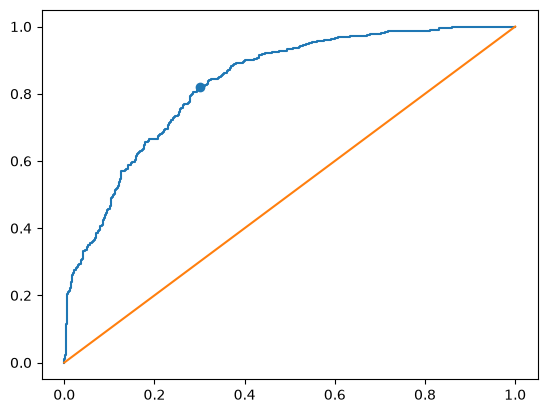

In [53]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [54]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.820855614973262
0.7320540156361052
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

[[723 310]
 [ 67 307]]


## naive bayes

In [55]:
from sklearn.naive_bayes import GaussianNB

In [56]:
nb = GaussianNB()
nb.fit(X1_train_transformed, y1_train_transformed)
y_pred=nb.predict(X1_test_transformed)
y_score=nb.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.66      0.76      1033
           1       0.46      0.81      0.59       374

    accuracy                           0.70      1407
   macro avg       0.68      0.73      0.67      1407
weighted avg       0.79      0.70      0.72      1407

[[678 355]
 [ 70 304]]


In [57]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(267), np.float64(0.9954070351484702))

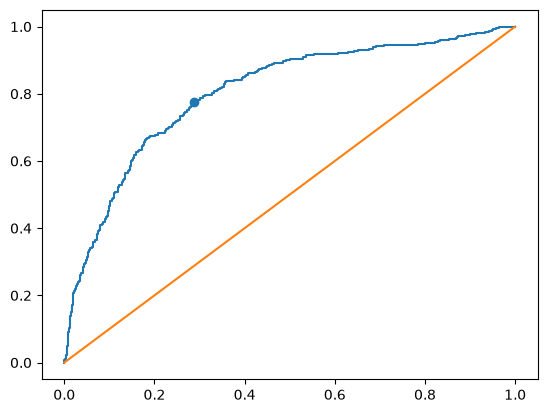

In [58]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [59]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.7754010695187166
0.7292110874200426
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407

[[736 297]
 [ 84 290]]


## knn

In [60]:
from sklearn.neighbors import KNeighborsClassifier

In [61]:
knn = KNeighborsClassifier()
knn.fit(X1_train_transformed, y1_train_transformed)
y_pred=knn.predict(X1_test_transformed)
y_score=knn.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76      1033
           1       0.44      0.69      0.53       374

    accuracy                           0.68      1407
   macro avg       0.65      0.68      0.65      1407
weighted avg       0.75      0.68      0.70      1407

[[702 331]
 [117 257]]


In [62]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(4), np.float64(0.4))

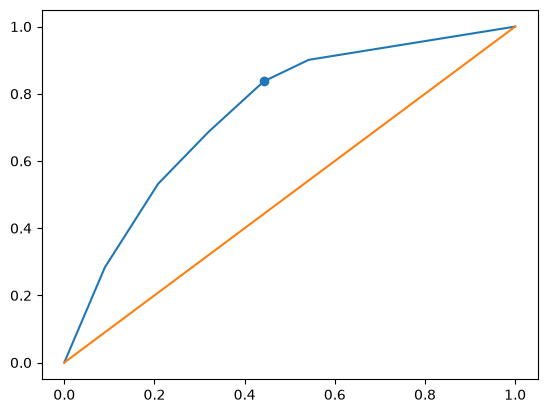

In [63]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [64]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.8368983957219251
0.6318407960199005
              precision    recall  f1-score   support

           0       0.90      0.56      0.69      1033
           1       0.41      0.84      0.55       374

    accuracy                           0.63      1407
   macro avg       0.66      0.70      0.62      1407
weighted avg       0.77      0.63      0.65      1407

[[576 457]
 [ 61 313]]


## svm

In [65]:
from sklearn.svm import SVC

In [67]:
svc = SVC()
svc.fit(X1_train_transformed, y1_train_transformed)
y_pred=svc.predict(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407

[[738 295]
 [ 84 290]]


## dt

In [68]:
from sklearn.tree import DecisionTreeClassifier

In [113]:
dtc = DecisionTreeClassifier(criterion="log_loss", max_depth=7, min_samples_leaf=92)
dtc.fit(X1_train_transformed, y1_train_transformed)
y_pred=dtc.predict(X1_test_transformed)
y_score=dtc.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.49      0.75      0.59       374

    accuracy                           0.73      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.73      0.74      1407

[[745 288]
 [ 94 280]]


In [114]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(17), np.float64(0.5268817204301075))

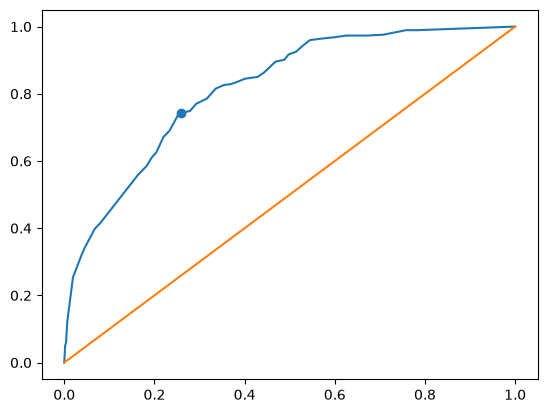

In [115]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [116]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.7433155080213903
0.7412935323383084
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.74      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407

[[765 268]
 [ 96 278]]


## rfc

In [117]:
from sklearn.ensemble import RandomForestClassifier

In [123]:
rfc = RandomForestClassifier(n_estimators=640, criterion="entropy", max_depth=9, min_samples_leaf=8, bootstrap=False, n_jobs=-1)
rfc.fit(X1_train_transformed, y1_train_transformed)
y_pred=rfc.predict(X1_test_transformed)
y_score=rfc.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.70      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

[[797 236]
 [114 260]]


In [124]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(283), np.float64(0.37095403223303103))

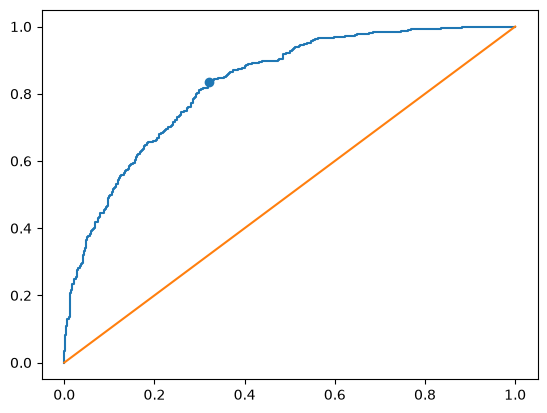

In [125]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [126]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.8342245989304813
0.7199715707178393
              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1033
           1       0.48      0.83      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.72      0.74      1407

[[701 332]
 [ 62 312]]


## adaboost

In [128]:
from sklearn.ensemble import AdaBoostClassifier

In [133]:
abc = AdaBoostClassifier(n_estimators=750, learning_rate=1.388)
abc.fit(X1_train_transformed, y1_train_transformed)
y_pred=abc.predict(X1_test_transformed)
y_score=abc.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1033
           1       0.57      0.64      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.78      0.78      1407

[[855 178]
 [136 238]]


In [134]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(266), np.float64(0.49393988068557215))

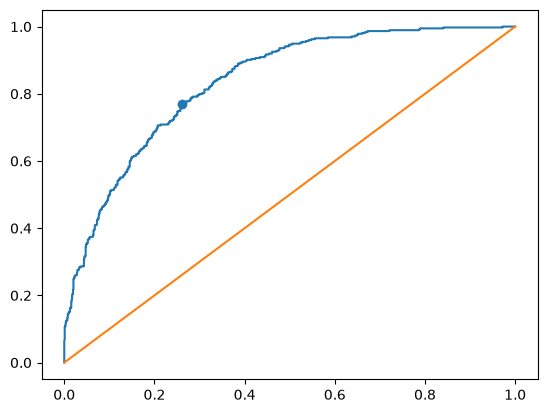

In [135]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [136]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.7700534759358288
0.7469793887704336
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.75      0.76      1407

[[763 270]
 [ 86 288]]


## Gradient boosting

In [138]:
from sklearn.ensemble import GradientBoostingClassifier

In [139]:
gbc = GradientBoostingClassifier(
        n_estimators=480,
        learning_rate=0.059000000000000004,
        min_samples_leaf=134,
        loss="log_loss"
    )
gbc.fit(X1_train_transformed, y1_train_transformed)
y_pred=gbc.predict(X1_test_transformed)
y_score=gbc.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.61      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407

[[871 162]
 [147 227]]


In [140]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(309), np.float64(0.19708047664966571))

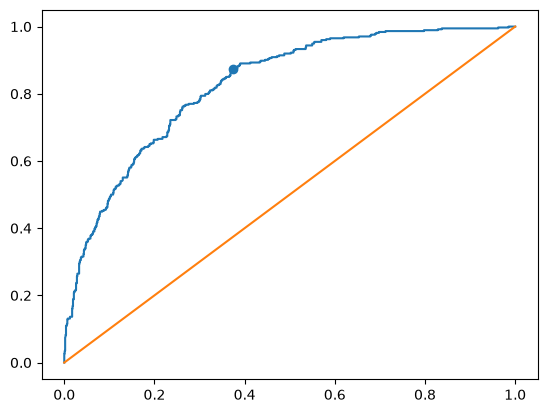

In [141]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [142]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.8743315508021391
0.6922530206112296
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1033
           1       0.46      0.87      0.60       374

    accuracy                           0.69      1407
   macro avg       0.70      0.75      0.68      1407
weighted avg       0.81      0.69      0.71      1407

[[647 386]
 [ 47 327]]


## eXtreme Gradient boosting

In [143]:
import xgboost as xgb

In [145]:
xgbc = xgb.XGBClassifier(
        objective="binary:logistic", n_estimators=660, learning_rate=0.8260000000000001, alpha=20.0
    )
xgbc.fit(X1_train_transformed, y1_train_transformed)
y_pred=xgbc.predict(X1_test_transformed)
y_score=xgbc.predict_proba(X1_test_transformed)

print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1033
           1       0.57      0.62      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.77      0.78      1407

[[854 179]
 [141 233]]


In [146]:
fpr, tpr, threshold = roc_curve(y1_test_transformed, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(278), np.float64(0.34134072065353394))

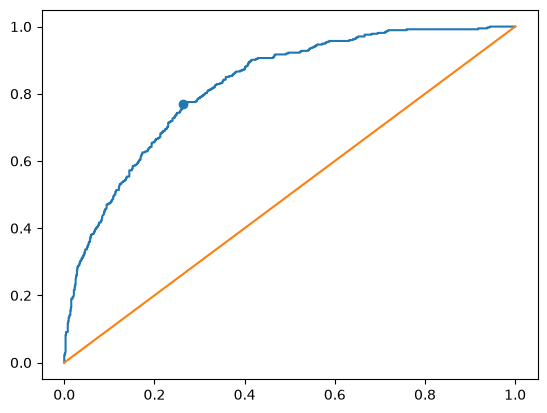

In [147]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [148]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(y1_test_transformed, y_pred))
print(accuracy_score(y1_test_transformed, y_pred))
print(classification_report(y1_test_transformed, y_pred))
print(confusion_matrix(y1_test_transformed, y_pred))

0.7700534759358288
0.7455579246624022
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.51      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.75      0.76      1407

[[761 272]
 [ 86 288]]


total charges didnt make any metric go up by a great margin so dropping was a nice decision

# 3 in 1 model

In [149]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [150]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [161]:
X=df.drop(columns=["Churn", "TotalCharges"])
y = df["Churn"]

## tts

In [162]:
from sklearn.model_selection import train_test_split

In [163]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [166]:
X2_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
6030,Female,0,No,No,43,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),49.05
3410,Male,0,No,No,3,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Credit card (automatic),53.40
5483,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,77.75
5524,Male,0,Yes,Yes,45,Yes,No,DSL,Yes,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),54.65
6337,Female,0,Yes,Yes,55,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,One year,No,Mailed check,100.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,Male,0,No,No,3,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),50.40
5199,Female,0,No,No,51,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,111.50
5235,Male,0,No,No,9,Yes,Yes,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,81.15
5399,Female,0,No,No,50,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.75


In [164]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.pipeline import Pipeline


In [168]:
featureResembling1= ColumnTransformer(
    [
        ("ohe", OneHotEncoder(sparse_output=False), [ "gender", "PaymentMethod", "Contract"]),
        (
            "oeYn", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[yn]*4)),
                ("scaler", MinMaxScaler()),
            ]
            ), 
            ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
            ),
        (
            "oeYnn", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[ynn])),
                ("scaler", MinMaxScaler())
            ]
            ), 
            ["MultipleLines"]
            ),
        (
            "oeYnn1", Pipeline(
            [
                ("oe", OrdinalEncoder(categories=[ynn1]*6)),
                ("scaler", MinMaxScaler())
            ]
            ) 
            ,["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
            ),
        ("stdScaling", Pipeline(
            [
                ("poly", PolynomialFeatures(degree=3)),
                ("scaling",StandardScaler())
                ]
            ), ["tenure", "MonthlyCharges"])
        ], remainder="passthrough"
)

In [170]:
X2_train_transformed = featureResembling1.fit_transform(X2_train)
X2_test_transformed = featureResembling1.transform(X2_test)

In [173]:
from sklearn.preprocessing import LabelEncoder

In [176]:
le = LabelEncoder()
y2_train_transformed = le.fit_transform(y2_train)
y2_test_transformed = le.transform(y2_test)

array([1, 1, 1, ..., 0, 0, 1], shape=(5625,))

In [194]:

def datasetSplitter(x, y):
    if x.shape[0] != y.shape[0]:
        print("no. of rows doesn't match")
        return None
    
    foX, dslX, noX = [], [], []
    foy, dsly, noy = [], [], []
    
    n = x.shape[0]
    for i in range(n):
        if x[i][-1] == "Fiber optic":
            foX.append(x[i][:-1])
            foy.append(y[i])
        elif x[i][-1] == "DSL":
            dslX.append(x[i][:-1])
            dsly.append(y[i])
        else:
            noX.append(x[i][:-1])
            noy.append(y[i])
    
    foX = np.array(foX)
    dslX = np.array(dslX)
    noX = np.array(noX)
    foy = np.array(foy)
    dsly = np.array(dsly)
    noy = np.array(noy)
    
    return foX, dslX, noX, foy, dsly, noy


In [195]:
foX, dslX, noX, foy, dsly, noy = datasetSplitter(X2_train_transformed, y2_train_transformed)

### foX 

In [230]:
foX_train, foX_test, foy_train, foy_test = train_test_split(
    foX, foy, test_size=0.2, random_state=42
)

#### log reg

In [231]:
lr = LogisticRegression(max_iter=1000)
lr.fit(foX_train, foy_train)
y_pred=lr.predict(foX_test)
y_score=lr.predict_proba(foX_test)

print(classification_report(foy_test, y_pred))
print(confusion_matrix(foy_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78       299
           1       0.66      0.71      0.69       196

    accuracy                           0.74       495
   macro avg       0.73      0.74      0.74       495
weighted avg       0.75      0.74      0.74       495

[[228  71]
 [ 56 140]]


In [232]:
fpr, tpr, threshold = roc_curve(foy_test, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(94), np.float64(0.4737317403395652))

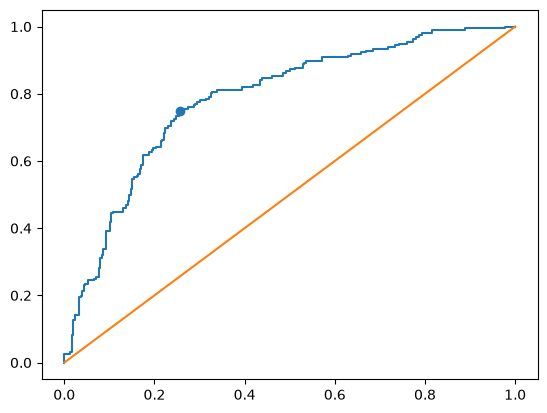

In [233]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [234]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(foy_test, y_pred))
print(accuracy_score(foy_test, y_pred))
print(classification_report(foy_test, y_pred))
print(confusion_matrix(foy_test, y_pred))

0.75
0.7454545454545455
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       299
           1       0.66      0.75      0.70       196

    accuracy                           0.75       495
   macro avg       0.74      0.75      0.74       495
weighted avg       0.75      0.75      0.75       495

[[222  77]
 [ 49 147]]


#### naive bayes

In [235]:
from sklearn.naive_bayes import GaussianNB

In [236]:
model = GaussianNB()
model.fit(foX_train, foy_train)
y_pred=model.predict(foX_test)
y_score=model.predict_proba(foX_test)

print(classification_report(foy_test, y_pred))
print(confusion_matrix(foy_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.58      0.68       299
           1       0.55      0.80      0.66       196

    accuracy                           0.67       495
   macro avg       0.69      0.69      0.67       495
weighted avg       0.71      0.67      0.67       495

[[173 126]
 [ 39 157]]


In [237]:
fpr, tpr, threshold = roc_curve(foy_test, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(94), np.float64(0.9982321329920427))

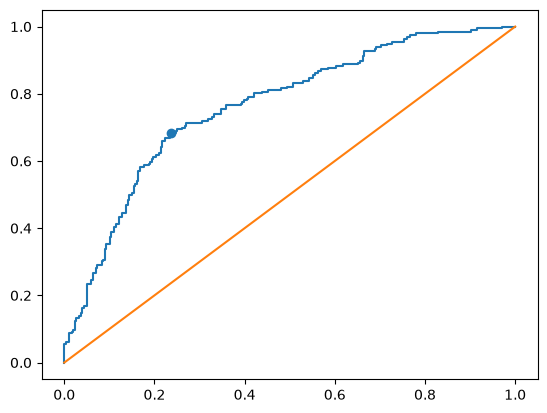

In [238]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [239]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(foy_test, y_pred))
print(accuracy_score(foy_test, y_pred))
print(classification_report(foy_test, y_pred))
print(confusion_matrix(foy_test, y_pred))

0.6836734693877551
0.7313131313131314
              precision    recall  f1-score   support

           0       0.79      0.76      0.77       299
           1       0.65      0.68      0.67       196

    accuracy                           0.73       495
   macro avg       0.72      0.72      0.72       495
weighted avg       0.73      0.73      0.73       495

[[228  71]
 [ 62 134]]


### dslX
 

In [240]:
dslX_train, dslX_test, dsly_train, dsly_test = train_test_split(
    dslX, dsly, test_size=0.2, random_state=42
)

#### log reg


In [241]:
lr = LogisticRegression(max_iter=1000)
lr.fit(dslX_train, dsly_train)
y_pred=lr.predict(dslX_test)
y_score=lr.predict_proba(dslX_test)

print(classification_report(dsly_test, y_pred))
print(confusion_matrix(dsly_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       311
           1       0.56      0.26      0.36        73

    accuracy                           0.82       384
   macro avg       0.70      0.61      0.63       384
weighted avg       0.79      0.82      0.79       384

[[296  15]
 [ 54  19]]


In [242]:
fpr, tpr, threshold = roc_curve(dsly_test, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(74), np.float64(0.14456759801296293))

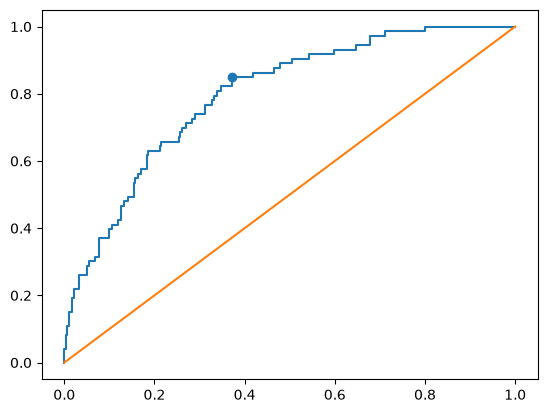

In [243]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [244]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(dsly_test, y_pred))
print(accuracy_score(dsly_test, y_pred))
print(classification_report(dsly_test, y_pred))
print(confusion_matrix(dsly_test, y_pred))

0.8493150684931506
0.6692708333333334
              precision    recall  f1-score   support

           0       0.95      0.63      0.75       311
           1       0.35      0.85      0.49        73

    accuracy                           0.67       384
   macro avg       0.65      0.74      0.62       384
weighted avg       0.83      0.67      0.70       384

[[195 116]
 [ 11  62]]


#### naive bayes

In [245]:
model.fit(dslX_train, dsly_train)
y_pred=model.predict(dslX_test)
y_score=model.predict_proba(dslX_test)

print(classification_report(dsly_test, y_pred))
print(confusion_matrix(dsly_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.58      0.71       311
           1       0.32      0.85      0.46        73

    accuracy                           0.63       384
   macro avg       0.63      0.71      0.59       384
weighted avg       0.82      0.63      0.67       384

[[179 132]
 [ 11  62]]


In [246]:
fpr, tpr, threshold = roc_curve(dsly_test, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(64), np.float64(0.9989076314514135))

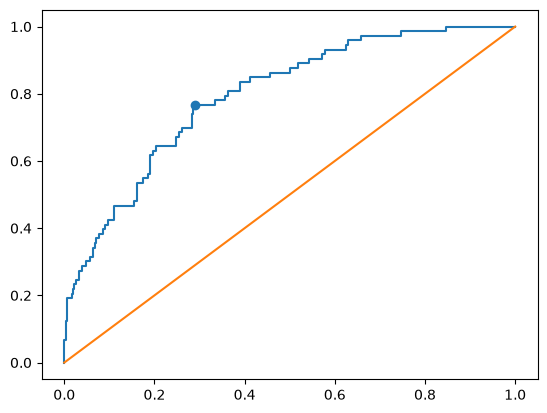

In [247]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [248]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(dsly_test, y_pred))
print(accuracy_score(dsly_test, y_pred))
print(classification_report(dsly_test, y_pred))
print(confusion_matrix(dsly_test, y_pred))

0.7671232876712328
0.7213541666666666
              precision    recall  f1-score   support

           0       0.93      0.71      0.81       311
           1       0.38      0.77      0.51        73

    accuracy                           0.72       384
   macro avg       0.66      0.74      0.66       384
weighted avg       0.82      0.72      0.75       384

[[221  90]
 [ 17  56]]


### noX

In [249]:
noX_train, noX_test, noy_train, noy_test = train_test_split(
    dslX, dsly, test_size=0.2, random_state=42
)

#### logreg

In [250]:
lr = LogisticRegression(max_iter=1000)
lr.fit(noX_train, noy_train)
y_pred=lr.predict(noX_test)
y_score=lr.predict_proba(noX_test)

print(classification_report(noy_test, y_pred))
print(confusion_matrix(noy_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       311
           1       0.56      0.26      0.36        73

    accuracy                           0.82       384
   macro avg       0.70      0.61      0.63       384
weighted avg       0.79      0.82      0.79       384

[[296  15]
 [ 54  19]]


In [251]:
fpr, tpr, threshold = roc_curve(noy_test, y_score[:,1])
idx=np.argmax(tpr-fpr)
idx , threshold[idx]

(np.int64(74), np.float64(0.14456759801296293))

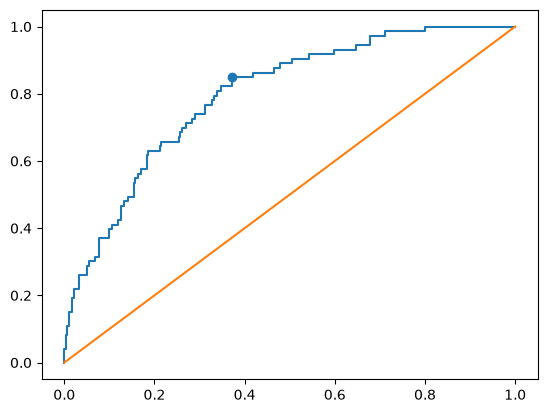

In [252]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.scatter(fpr[idx], tpr[idx])
plt.show()

In [253]:
y_pred=list()
y_score1=y_score[:,1]
for i in y_score1:
    if i<threshold[idx]:
        y_pred.append(0)
        continue
    y_pred.append(1)
print(recall_score(noy_test, y_pred))
print(accuracy_score(noy_test, y_pred))
print(classification_report(noy_test, y_pred))
print(confusion_matrix(noy_test, y_pred))

0.8493150684931506
0.6692708333333334
              precision    recall  f1-score   support

           0       0.95      0.63      0.75       311
           1       0.35      0.85      0.49        73

    accuracy                           0.67       384
   macro avg       0.65      0.74      0.62       384
weighted avg       0.83      0.67      0.70       384

[[195 116]
 [ 11  62]]


3 segment model shows no improvement in results so discarding it without going any further